MAT 302: DIFFERENTIAL EQUATIONS - COMPREHENSIVE DEMONSTRATION

MODULE 1: Initial and Boundary Value Problems

Example 1.1: Solve dy/dt = -2y + exp(-t), y(0) = 1
Solution computed with RK45
y(5) ≈ 0.006744
Exact y(5) = 0.013430

Example 1.2: Solve y'' + 4y = 0, y(0) = 1, y'(0) = 0
y(π) ≈ 0.999911 (should be ≈ -1)

Example 1.3: BVP y'' = -y, y(0) = 0, y(π/2) = 1
Solution at midpoint: y(π/4) ≈ 0.712731
(Exact: sin(π/4) = 0.707107)

Example 1.4: Compare numerical methods for dy/dt = -y, y(0) = 1

Method Comparison (max errors):
  Euler          : 1.96e-02
  Heun           : 6.90e-04
  Midpoint       : 6.90e-04
  RK4            : 3.62e-07
  RK45           : 4.58e-04

MODULE 2: Linear Systems of ODEs with Constant Coefficients

Example 2.1: Solve dY/dt = AY where A = [[-1, 2], [0, -3]]
Eigenvalues: [-1.+0.j -3.+0.j]
Y(5) ≈ [0.013476, 0.000000]

Example 2.2: System with complex eigenvalues A = [[0, 1], [-4, 0]]
Eigenvalues: [0.+2.j 0.-2.j]
General solution form: Y(t) = exp(0.0000*t) * [c1*cos

C:\Users\Admin\AppData\Local\Temp\ipykernel_34880\3782428753.py:1427: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(integrand, t_segment)



r = 3.9:
  Fixed points: [np.float64(0.0), np.float64(0.7435897435897436)]
  Lyapunov exponent: 0.5027
  Attractor type: Chaotic attractor

Example 10.2: Period-2 orbits in logistic map (r = 3.2)
Period-2 orbit: [np.float64(0.5130445095326299), np.float64(0.7994554904673701)]

Example 10.3: Stability of fixed points in logistic map

r = 2.0:
  x* = 0.0000: f'(x*) = 2.0000
    Unstable, Unstable Node (monotone divergence)
  x* = 0.5000: f'(x*) = 0.0000
    Asymptotically Stable, Stable Node (monotone convergence)

r = 3.0:
  x* = 0.0000: f'(x*) = 3.0000
    Unstable, Unstable Node (monotone divergence)
  x* = 0.6667: f'(x*) = -1.0000
    Unstable, Unstable Node (oscillatory divergence)

r = 3.5:
  x* = 0.0000: f'(x*) = 3.5000
    Unstable, Unstable Node (monotone divergence)
  x* = 0.7143: f'(x*) = -1.5000
    Unstable, Unstable Node (oscillatory divergence)

Example 10.4: Hénon map analysis
Parameters: a = 1.4, b = 0.3
Fixed points: [array([0.63135448, 0.18940634]), array([-1.13135448

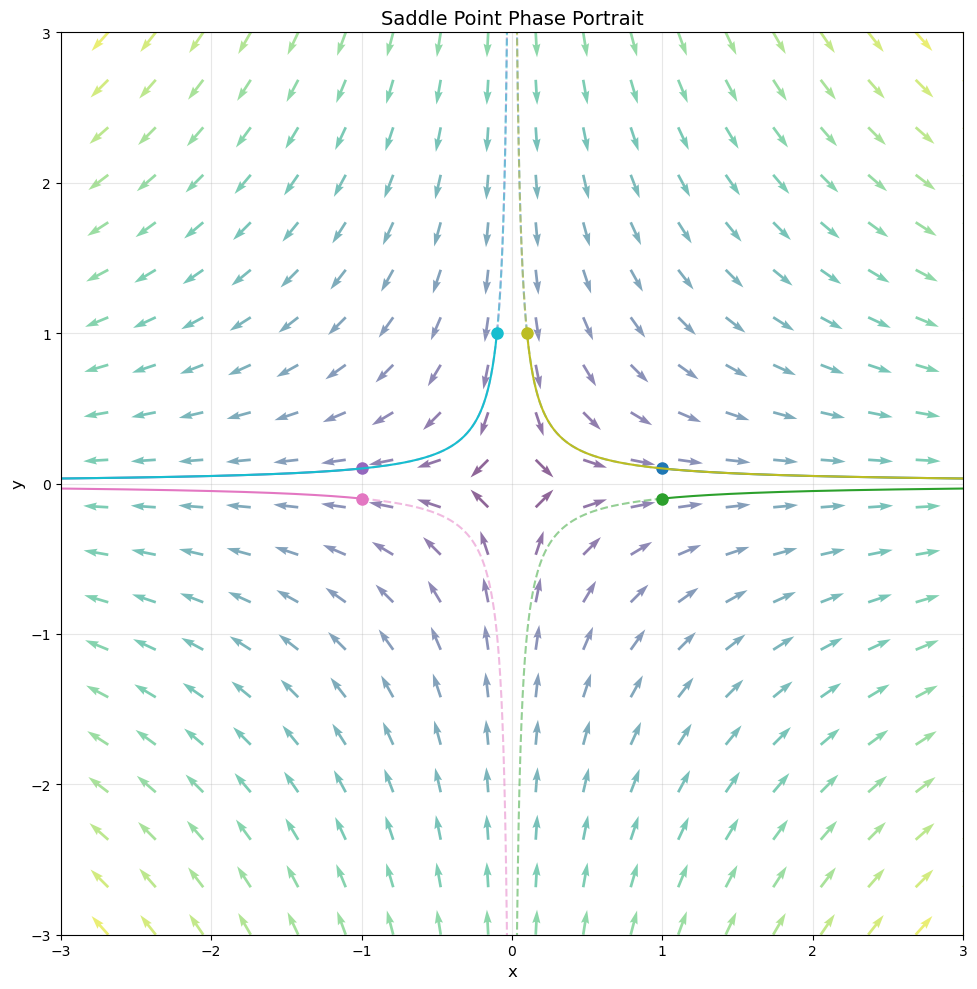

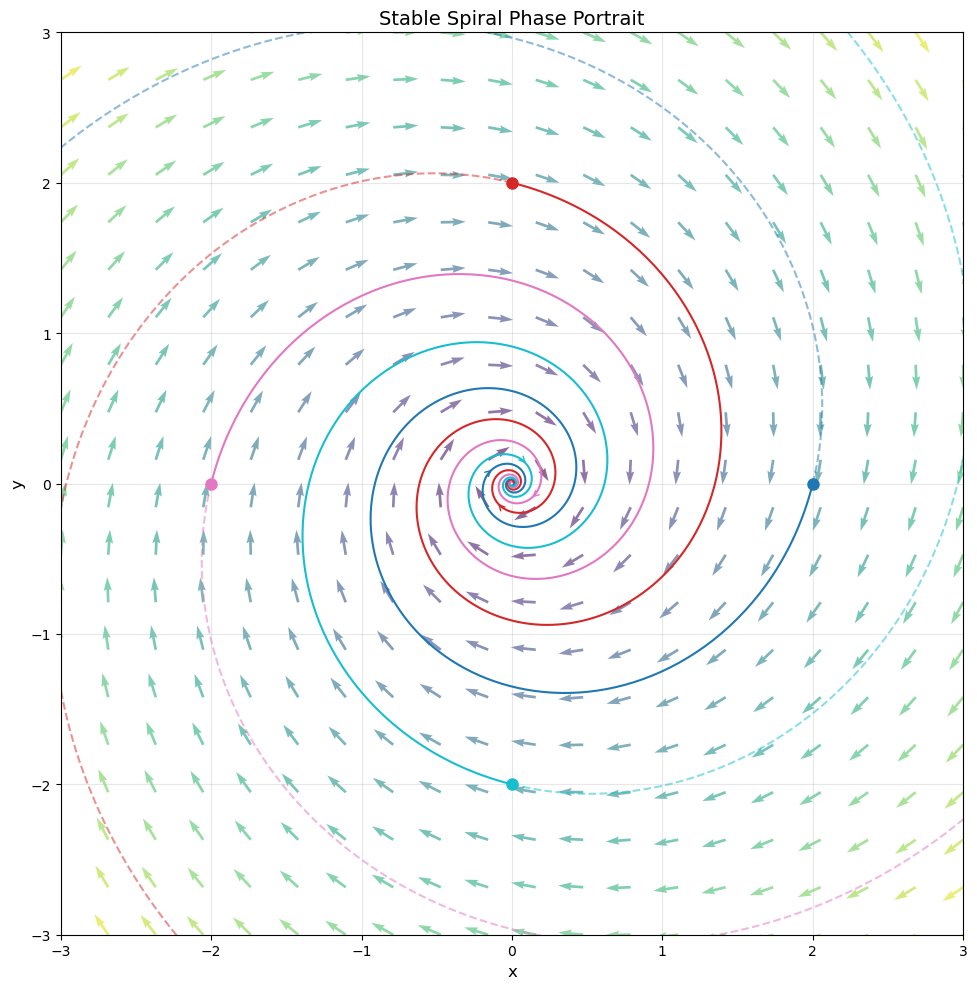

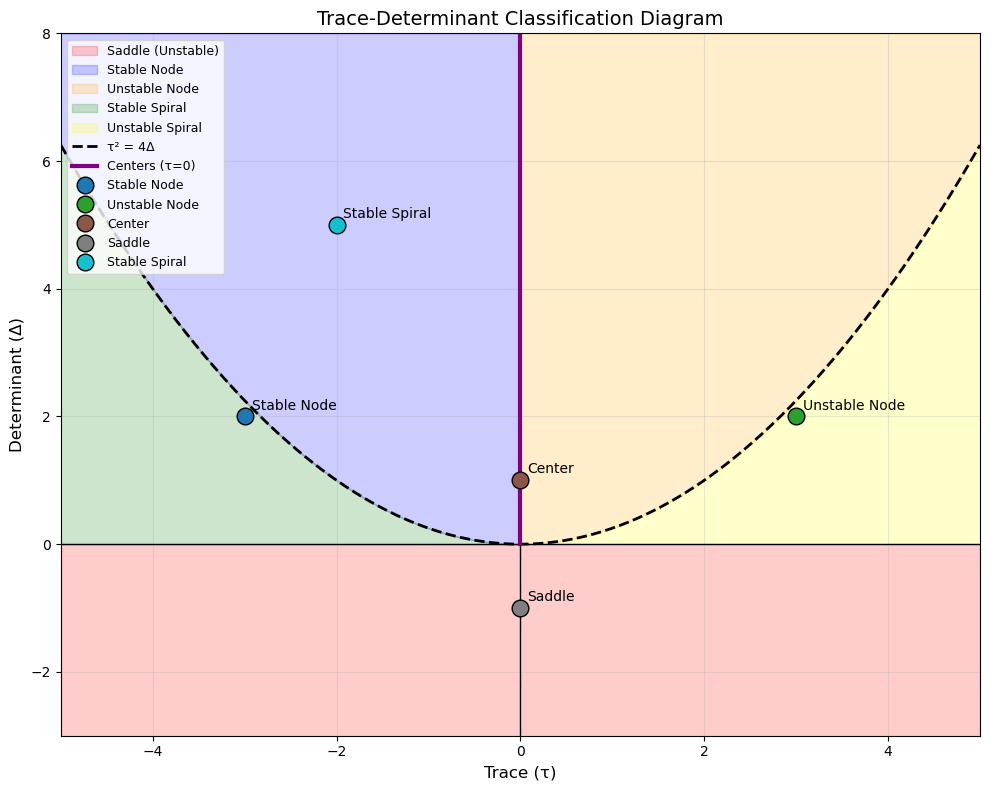

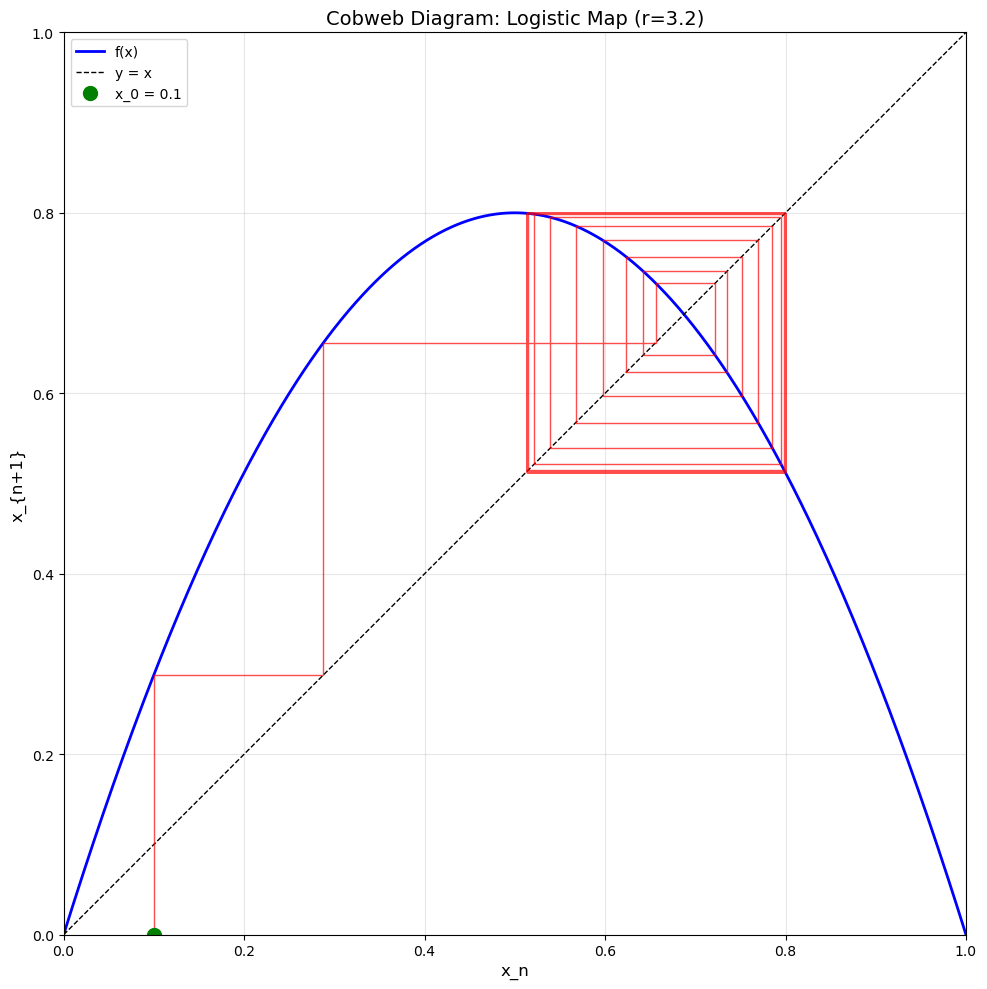

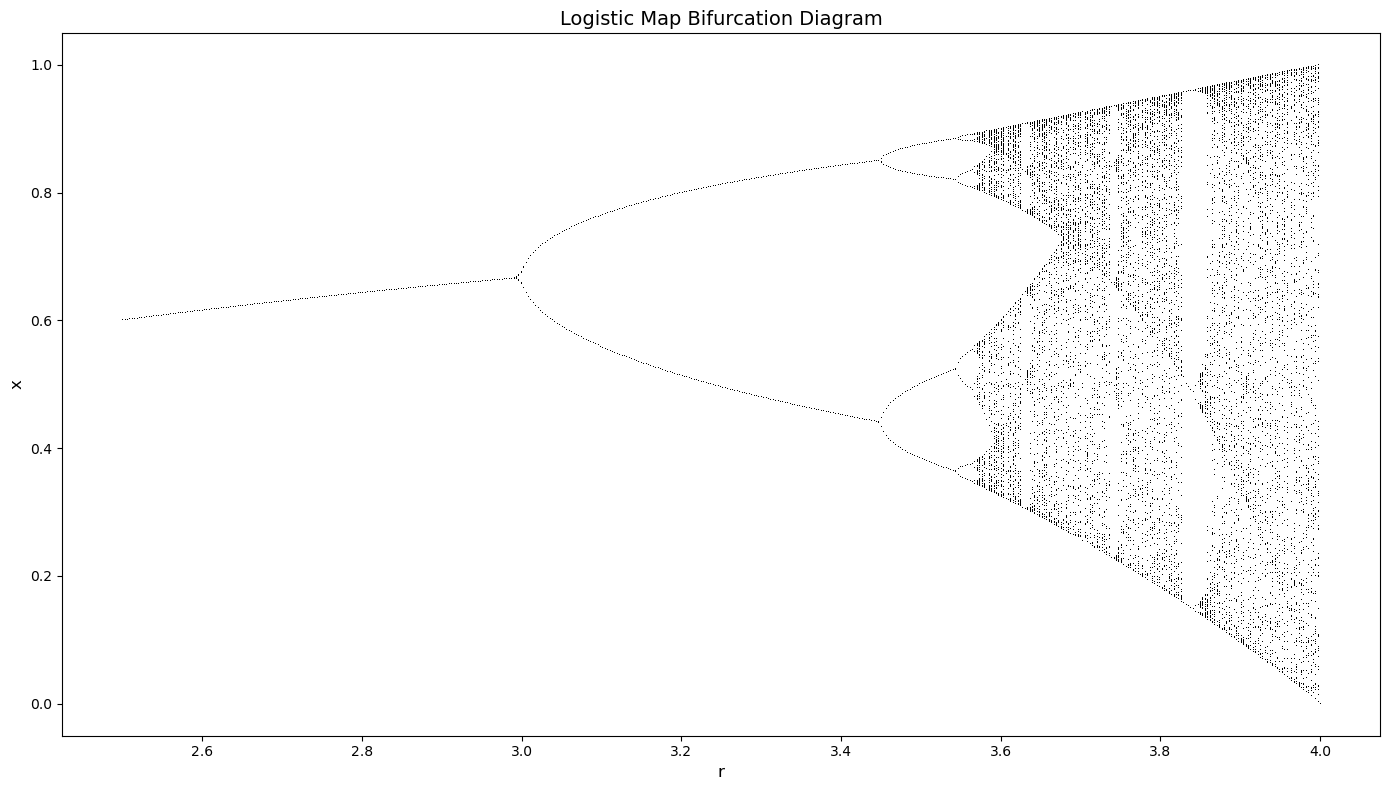

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.linalg import eig, expm, solve, lstsq
from scipy.optimize import fsolve, brentq
from typing import Callable, Tuple, List, Optional, Union, Dict, Any
from dataclasses import dataclass, field
from enum import Enum
import warnings
from functools import lru_cache
import sympy as sp
from sympy import symbols, Function, dsolve, Eq, exp, sin, cos, Matrix
from sympy import lambdify, simplify, solve as sp_solve, diff, det, trace
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches


class EquilibriumType(Enum):
    """Classification of equilibrium points"""
    STABLE_NODE = "Stable Node"
    UNSTABLE_NODE = "Unstable Node"
    STABLE_SPIRAL = "Stable Spiral (Focus)"
    UNSTABLE_SPIRAL = "Unstable Spiral (Focus)"
    CENTER = "Center"
    SADDLE = "Saddle Point"
    STABLE_STAR = "Stable Star Node"
    UNSTABLE_STAR = "Unstable Star Node"
    STABLE_DEGENERATE = "Stable Degenerate Node"
    UNSTABLE_DEGENERATE = "Unstable Degenerate Node"
    NON_ISOLATED = "Non-Isolated Fixed Point"
    UNKNOWN = "Unknown"


class StabilityType(Enum):
    """Stability classification"""
    ASYMPTOTICALLY_STABLE = "Asymptotically Stable"
    STABLE = "Stable (Lyapunov)"
    UNSTABLE = "Unstable"
    MARGINALLY_STABLE = "Marginally Stable"


@dataclass
class Solution:
    """Container for solution results"""
    t: np.ndarray
    y: np.ndarray
    method: str
    success: bool = True
    message: str = ""
    analytical: Optional[str] = None
    eigenvalues: Optional[np.ndarray] = None
    eigenvectors: Optional[np.ndarray] = None
    equilibria: Optional[List[np.ndarray]] = None
    stability: Optional[List[dict]] = None
    extra: Dict[str, Any] = field(default_factory=dict)


@dataclass
class SystemAnalysis:
    """Container for system analysis results"""
    matrix: np.ndarray
    eigenvalues: np.ndarray
    eigenvectors: np.ndarray
    trace: float
    determinant: float
    discriminant: float
    equilibrium_type: EquilibriumType
    stability: StabilityType
    general_solution: Optional[str] = None
    fundamental_matrix: Optional[np.ndarray] = None


class DifferentialEquationsSolver:
    """
    Comprehensive solver for MAT 302: Differential Equations with Numerical Methods
    
    Covers all modules:
    - Module 1: Initial and Boundary Value Problems
    - Module 2: Linear Systems of ODEs with Constant Coefficients
    - Module 3: Phase Portraits and Planar Systems
    - Module 4: Stability and Classification of Subspaces
    - Module 5: Trace and Determinant in System Classification
    - Module 6: Inhomogeneous Linear Systems
    - Module 7: Nonlinear Systems and Linearization
    - Module 8: Existence and Uniqueness of Solutions
    - Module 9: Introduction to Difference Equations
    - Module 10: Nonlinear Difference Equations and Systems
    """
    
    def __init__(self, tolerance: float = 1e-10):
        self.tol = tolerance
        self.t_sym = symbols('t')
        self.x_sym = symbols('x')
        self.y_sym = symbols('y')
        
    # ========================================================================
    # MODULE 1: Initial and Boundary Value Problems
    # ========================================================================
    
    def solve_first_order_ivp(self, 
                               f: Callable[[float, float], float],
                               t_span: Tuple[float, float],
                               y0: float,
                               method: str = 'RK45',
                               t_eval: Optional[np.ndarray] = None,
                               **kwargs) -> Solution:
        """
        Solve first-order IVP: dy/dt = f(t, y), y(t0) = y0
        
        Parameters:
        -----------
        f : callable
            Right-hand side function f(t, y)
        t_span : tuple
            (t_start, t_end)
        y0 : float
            Initial condition
        method : str
            'RK45', 'RK23', 'DOP853', 'Radau', 'BDF', 'LSODA',
            'Euler', 'Heun', 'RK4', 'Midpoint', 'AdamsBashforth'
        """
        if t_eval is None:
            t_eval = np.linspace(t_span[0], t_span[1], 1000)
            
        if method in ['Euler', 'Heun', 'RK4', 'Midpoint', 'AdamsBashforth']:
            t, y = self._custom_integrator(f, t_span, y0, t_eval, method)
            return Solution(t=t, y=y, method=method)
        else:
            sol = solve_ivp(f, t_span, [y0], method=method, t_eval=t_eval, **kwargs)
            return Solution(t=sol.t, y=sol.y[0], method=method, 
                          success=sol.success, message=sol.message)
    
    def solve_higher_order_ivp(self,
                                f: Callable,
                                order: int,
                                t_span: Tuple[float, float],
                                initial_conditions: List[float],
                                method: str = 'RK45',
                                t_eval: Optional[np.ndarray] = None) -> Solution:
        """
        Solve nth-order IVP by converting to first-order system
        
        For y^(n) = f(t, y, y', y'', ..., y^(n-1))
        with initial conditions [y(t0), y'(t0), ..., y^(n-1)(t0)]
        """
        def system(t, Y):
            dY = np.zeros(order)
            dY[:-1] = Y[1:]
            dY[-1] = f(t, *Y)
            return dY
        
        if t_eval is None:
            t_eval = np.linspace(t_span[0], t_span[1], 1000)
            
        sol = solve_ivp(system, t_span, initial_conditions, 
                       method=method, t_eval=t_eval)
        return Solution(t=sol.t, y=sol.y, method=method,
                       success=sol.success, message=sol.message)
    
    def solve_bvp_shooting(self,
                           f: Callable[[float, np.ndarray], np.ndarray],
                           t_span: Tuple[float, float],
                           bc_left: float,
                           bc_right: float,
                           guess: float = 0.0,
                           n_points: int = 100) -> Solution:
        """
        Solve two-point BVP using shooting method
        
        y'' = f(t, [y, y'])
        y(a) = bc_left, y(b) = bc_right
        """
        t_eval = np.linspace(t_span[0], t_span[1], n_points)
        
        def residual(slope):
            sol = solve_ivp(f, t_span, [bc_left, slope], t_eval=t_eval)
            return sol.y[0, -1] - bc_right
        
        try:
            optimal_slope = brentq(residual, guess - 100, guess + 100)
        except ValueError:
            optimal_slope = fsolve(residual, guess)[0]
            
        sol = solve_ivp(f, t_span, [bc_left, optimal_slope], t_eval=t_eval)
        return Solution(t=sol.t, y=sol.y, method='Shooting',
                       extra={'initial_slope': optimal_slope})
    
    def solve_bvp_finite_difference(self,
                                     p: Callable[[float], float],
                                     q: Callable[[float], float],
                                     r: Callable[[float], float],
                                     t_span: Tuple[float, float],
                                     bc_left: float,
                                     bc_right: float,
                                     n_points: int = 100) -> Solution:
        """
        Solve linear BVP using finite differences
        
        y'' + p(t)y' + q(t)y = r(t)
        y(a) = bc_left, y(b) = bc_right
        """
        a, b = t_span
        h = (b - a) / (n_points - 1)
        t = np.linspace(a, b, n_points)
        
        # Interior points
        n_interior = n_points - 2
        A = np.zeros((n_interior, n_interior))
        b_vec = np.zeros(n_interior)
        
        for i in range(n_interior):
            ti = t[i + 1]
            pi, qi, ri = p(ti), q(ti), r(ti)
            
            # Coefficients for y_{i-1}, y_i, y_{i+1}
            coef_left = 1/h**2 - pi/(2*h)
            coef_center = -2/h**2 + qi
            coef_right = 1/h**2 + pi/(2*h)
            
            if i > 0:
                A[i, i-1] = coef_left
            A[i, i] = coef_center
            if i < n_interior - 1:
                A[i, i+1] = coef_right
                
            b_vec[i] = ri
            if i == 0:
                b_vec[i] -= coef_left * bc_left
            if i == n_interior - 1:
                b_vec[i] -= coef_right * bc_right
        
        y_interior = solve(A, b_vec)
        y = np.concatenate([[bc_left], y_interior, [bc_right]])
        
        return Solution(t=t, y=y, method='Finite Difference')
    
    def solve_symbolic_ode(self,
                           ode_expr: str,
                           dependent_var: str = 'y',
                           independent_var: str = 't',
                           ics: Optional[Dict] = None) -> Solution:
        """
        Solve ODE symbolically using SymPy
        
        Parameters:
        -----------
        ode_expr : str
            ODE expression, e.g., "y'' + 2*y' + y - exp(-t)"
        ics : dict
            Initial conditions, e.g., {y(0): 1, y'(0): 0}
        """
        t = symbols(independent_var)
        y = Function(dependent_var)(t)
        
        # Parse the expression
        local_dict = {dependent_var: y, independent_var: t, 
                     f"{dependent_var}'": diff(y, t),
                     f"{dependent_var}''": diff(y, t, 2),
                     f"{dependent_var}'''": diff(y, t, 3)}
        
        expr = sp.sympify(ode_expr, locals=local_dict)
        eq = Eq(expr, 0)
        
        # Solve
        if ics:
            solution = dsolve(eq, y, ics=ics)
        else:
            solution = dsolve(eq, y)
            
        return Solution(t=np.array([]), y=np.array([]), 
                       method='Symbolic', analytical=str(solution))
    
    def _custom_integrator(self, f, t_span, y0, t_eval, method):
        """Implement custom numerical integrators"""
        n = len(t_eval)
        y = np.zeros(n)
        y[0] = y0
        
        for i in range(n - 1):
            h = t_eval[i+1] - t_eval[i]
            t_i, y_i = t_eval[i], y[i]
            
            if method == 'Euler':
                y[i+1] = y_i + h * f(t_i, y_i)
                
            elif method == 'Heun':
                k1 = f(t_i, y_i)
                k2 = f(t_i + h, y_i + h * k1)
                y[i+1] = y_i + h/2 * (k1 + k2)
                
            elif method == 'Midpoint':
                k1 = f(t_i, y_i)
                k2 = f(t_i + h/2, y_i + h/2 * k1)
                y[i+1] = y_i + h * k2
                
            elif method == 'RK4':
                k1 = f(t_i, y_i)
                k2 = f(t_i + h/2, y_i + h/2 * k1)
                k3 = f(t_i + h/2, y_i + h/2 * k2)
                k4 = f(t_i + h, y_i + h * k3)
                y[i+1] = y_i + h/6 * (k1 + 2*k2 + 2*k3 + k4)
                
            elif method == 'AdamsBashforth':
                if i < 3:
                    # Bootstrap with RK4
                    k1 = f(t_i, y_i)
                    k2 = f(t_i + h/2, y_i + h/2 * k1)
                    k3 = f(t_i + h/2, y_i + h/2 * k2)
                    k4 = f(t_i + h, y_i + h * k3)
                    y[i+1] = y_i + h/6 * (k1 + 2*k2 + 2*k3 + k4)
                else:
                    # Adams-Bashforth 4-step
                    f0 = f(t_eval[i], y[i])
                    f1 = f(t_eval[i-1], y[i-1])
                    f2 = f(t_eval[i-2], y[i-2])
                    f3 = f(t_eval[i-3], y[i-3])
                    y[i+1] = y_i + h/24 * (55*f0 - 59*f1 + 37*f2 - 9*f3)
                    
        return t_eval, y
    
    # ========================================================================
    # MODULE 2: Linear Systems of ODEs with Constant Coefficients
    # ========================================================================
    
    def solve_linear_system(self,
                            A: np.ndarray,
                            t_span: Tuple[float, float],
                            y0: np.ndarray,
                            method: str = 'analytical',
                            t_eval: Optional[np.ndarray] = None) -> Solution:
        """
        Solve linear system: dY/dt = A*Y, Y(0) = y0
        
        Parameters:
        -----------
        A : ndarray
            Constant coefficient matrix
        method : str
            'analytical' (matrix exponential), 'eigenvalue', or numerical methods
        """
        A = np.array(A, dtype=float)
        y0 = np.array(y0, dtype=float)
        
        if t_eval is None:
            t_eval = np.linspace(t_span[0], t_span[1], 1000)
        
        eigenvalues, eigenvectors = eig(A)
        tr = np.trace(A)
        det_A = np.linalg.det(A)
        
        if method == 'analytical':
            # Use matrix exponential
            Y = np.zeros((len(y0), len(t_eval)))
            for i, t in enumerate(t_eval):
                Y[:, i] = expm(A * t) @ y0
                
            return Solution(t=t_eval, y=Y, method='Matrix Exponential',
                          eigenvalues=eigenvalues, eigenvectors=eigenvectors,
                          extra={'trace': tr, 'determinant': det_A})
        
        elif method == 'eigenvalue':
            # Construct solution from eigenvalue decomposition
            Y = self._solve_by_eigenvalues(A, y0, t_eval, eigenvalues, eigenvectors)
            general_sol = self._construct_general_solution(eigenvalues, eigenvectors)
            
            return Solution(t=t_eval, y=Y, method='Eigenvalue Decomposition',
                          eigenvalues=eigenvalues, eigenvectors=eigenvectors,
                          analytical=general_sol,
                          extra={'trace': tr, 'determinant': det_A})
        else:
            # Numerical solution
            def system(t, Y):
                return A @ Y
            sol = solve_ivp(system, t_span, y0, method=method, t_eval=t_eval)
            return Solution(t=sol.t, y=sol.y, method=method,
                          eigenvalues=eigenvalues, eigenvectors=eigenvectors)
    
    def _solve_by_eigenvalues(self, A, y0, t_eval, eigenvalues, eigenvectors):
        """Solve using eigenvalue decomposition"""
        n = len(eigenvalues)
        Y = np.zeros((n, len(t_eval)), dtype=complex)
        
        # Check for repeated eigenvalues
        unique_eigs, counts = np.unique(np.round(eigenvalues, 10), return_counts=True)
        
        if np.max(counts) == 1:
            # All distinct eigenvalues
            try:
                coeffs = solve(eigenvectors, y0)
                for i, t in enumerate(t_eval):
                    for j in range(n):
                        Y[:, i] += coeffs[j] * np.exp(eigenvalues[j] * t) * eigenvectors[:, j]
            except:
                # Fallback to matrix exponential
                for i, t in enumerate(t_eval):
                    Y[:, i] = expm(A * t) @ y0
        else:
            # Has repeated eigenvalues - use matrix exponential
            for i, t in enumerate(t_eval):
                Y[:, i] = expm(A * t) @ y0
                
        return np.real(Y) if np.allclose(np.imag(Y), 0) else Y
    
    def _construct_general_solution(self, eigenvalues, eigenvectors):
        """Construct string representation of general solution"""
        n = len(eigenvalues)
        terms = []
        
        for i in range(n):
            lam = eigenvalues[i]
            v = eigenvectors[:, i]
            
            if np.isreal(lam):
                lam = np.real(lam)
                v_str = f"[{', '.join([f'{np.real(x):.4f}' for x in v])}]"
                if abs(lam) < 1e-10:
                    terms.append(f"c{i+1} * {v_str}")
                else:
                    terms.append(f"c{i+1} * exp({lam:.4f}*t) * {v_str}")
            else:
                if np.imag(lam) > 0:
                    alpha, beta = np.real(lam), np.imag(lam)
                    v_real = np.real(v)
                    v_imag = np.imag(v)
                    terms.append(f"exp({alpha:.4f}*t) * [c{i+1}*cos({beta:.4f}*t) + c{i+2}*sin({beta:.4f}*t)] * vectors")
                    
        return "Y(t) = " + " + ".join(terms[:n])
    
    def fundamental_matrix(self, A: np.ndarray, t: float = 1.0) -> np.ndarray:
        """
        Compute fundamental matrix Φ(t) = exp(At)
        """
        return expm(np.array(A) * t)
    
    def compute_general_solution_symbolic(self, A: np.ndarray) -> str:
        """
        Compute symbolic general solution for 2x2 or 3x3 systems
        """
        t = symbols('t')
        A_sym = Matrix(A)
        
        eigenvals = A_sym.eigenvals()
        eigenvects = A_sym.eigenvects()
        
        solution_parts = []
        const_idx = 1
        
        for eigenval, multiplicity, vects in eigenvects:
            if multiplicity == 1:
                v = vects[0]
                term = f"c{const_idx} * exp({eigenval}*t) * {v.T}"
                solution_parts.append(term)
                const_idx += 1
            else:
                # Handle repeated eigenvalues
                for i, v in enumerate(vects):
                    if i == 0:
                        term = f"c{const_idx} * exp({eigenval}*t) * {v.T}"
                    else:
                        term = f"c{const_idx} * t^{i} * exp({eigenval}*t) * {v.T}"
                    solution_parts.append(term)
                    const_idx += 1
                    
        return "Y(t) = " + " + ".join(solution_parts)
    
    # ========================================================================
    # MODULE 3: Phase Portraits and Planar Systems
    # ========================================================================
    
    def plot_phase_portrait(self,
                            f: Callable[[np.ndarray, float], np.ndarray],
                            x_range: Tuple[float, float] = (-5, 5),
                            y_range: Tuple[float, float] = (-5, 5),
                            n_grid: int = 20,
                            trajectories: Optional[List[np.ndarray]] = None,
                            t_span: Tuple[float, float] = (0, 10),
                            title: str = "Phase Portrait",
                            show_nullclines: bool = False,
                            equilibria: Optional[List[np.ndarray]] = None,
                            figsize: Tuple[int, int] = (10, 10)) -> plt.Figure:
        """
        Create comprehensive phase portrait
        
        Parameters:
        -----------
        f : callable
            System function f([x, y], t) returning [dx/dt, dy/dt]
        trajectories : list
            List of initial conditions for trajectories
        """
        fig, ax = plt.subplots(figsize=figsize)
        
        # Create grid
        x = np.linspace(x_range[0], x_range[1], n_grid)
        y = np.linspace(y_range[0], y_range[1], n_grid)
        X, Y = np.meshgrid(x, y)
        
        # Compute vector field
        U = np.zeros_like(X)
        V = np.zeros_like(Y)
        
        for i in range(n_grid):
            for j in range(n_grid):
                vec = f(np.array([X[i,j], Y[i,j]]), 0)
                U[i,j] = vec[0]
                V[i,j] = vec[1]
        
        # Normalize for better visualization
        magnitude = np.sqrt(U**2 + V**2)
        magnitude[magnitude == 0] = 1
        U_norm = U / magnitude
        V_norm = V / magnitude
        
        # Plot vector field
        ax.quiver(X, Y, U_norm, V_norm, magnitude, cmap='viridis', alpha=0.6)
        
        # Plot nullclines
        if show_nullclines:
            ax.contour(X, Y, U, levels=[0], colors='red', linestyles='--', linewidths=2)
            ax.contour(X, Y, V, levels=[0], colors='blue', linestyles='--', linewidths=2)
            ax.plot([], [], 'r--', label='x-nullcline (dx/dt=0)')
            ax.plot([], [], 'b--', label='y-nullcline (dy/dt=0)')
        
        # Plot trajectories
        if trajectories is not None:
            colors = plt.cm.tab10(np.linspace(0, 1, len(trajectories)))
            t_eval = np.linspace(t_span[0], t_span[1], 1000)
            
            for ic, color in zip(trajectories, colors):
                # Forward trajectory
                try:
                    sol = solve_ivp(lambda t, y: f(y, t), t_span, ic, 
                                   t_eval=t_eval, method='RK45')
                    ax.plot(sol.y[0], sol.y[1], color=color, linewidth=1.5)
                    ax.plot(ic[0], ic[1], 'o', color=color, markersize=8)
                    
                    # Add arrow
                    mid = len(sol.t) // 2
                    ax.annotate('', xy=(sol.y[0,mid+1], sol.y[1,mid+1]),
                               xytext=(sol.y[0,mid], sol.y[1,mid]),
                               arrowprops=dict(arrowstyle='->', color=color))
                except:
                    pass
                
                # Backward trajectory
                try:
                    sol_back = solve_ivp(lambda t, y: f(y, t), 
                                        (t_span[0], -t_span[1]), ic,
                                        t_eval=-t_eval, method='RK45')
                    ax.plot(sol_back.y[0], sol_back.y[1], color=color, 
                           linewidth=1.5, linestyle='--', alpha=0.5)
                except:
                    pass
        
        # Mark equilibria
        if equilibria is not None:
            for eq in equilibria:
                ax.plot(eq[0], eq[1], 'ko', markersize=10, markerfacecolor='white',
                       markeredgewidth=2)
        
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('y', fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        if show_nullclines:
            ax.legend()
            
        plt.tight_layout()
        return fig
    
    def plot_3d_phase_space(self,
                            f: Callable[[np.ndarray, float], np.ndarray],
                            trajectories: List[np.ndarray],
                            t_span: Tuple[float, float] = (0, 10),
                            title: str = "3D Phase Space",
                            figsize: Tuple[int, int] = (12, 10)) -> plt.Figure:
        """
        Create 3D phase space visualization
        """
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection='3d')
        
        colors = plt.cm.viridis(np.linspace(0, 1, len(trajectories)))
        t_eval = np.linspace(t_span[0], t_span[1], 1000)
        
        for ic, color in zip(trajectories, colors):
            sol = solve_ivp(lambda t, y: f(y, t), t_span, ic, 
                           t_eval=t_eval, method='RK45')
            ax.plot(sol.y[0], sol.y[1], sol.y[2], color=color, linewidth=1)
            ax.scatter(ic[0], ic[1], ic[2], color=color, s=50, marker='o')
        
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title(title)
        
        return fig
    
    def plot_solution_components(self,
                                 solution: Solution,
                                 labels: Optional[List[str]] = None,
                                 title: str = "Solution Components",
                                 figsize: Tuple[int, int] = (12, 8)) -> plt.Figure:
        """
        Plot individual components of solution vs time
        """
        fig, axes = plt.subplots(solution.y.shape[0], 1, figsize=figsize, sharex=True)
        
        if solution.y.ndim == 1:
            axes = [axes]
            y_data = [solution.y]
        else:
            y_data = solution.y
            
        if labels is None:
            labels = [f'y_{i+1}' for i in range(len(y_data))]
            
        for i, (ax, y, label) in enumerate(zip(axes, y_data, labels)):
            ax.plot(solution.t, y, 'b-', linewidth=1.5)
            ax.set_ylabel(label, fontsize=12)
            ax.grid(True, alpha=0.3)
            
        axes[-1].set_xlabel('t', fontsize=12)
        axes[0].set_title(title, fontsize=14)
        
        plt.tight_layout()
        return fig
    
    # ========================================================================
    # MODULE 4: Stability and Classification of Subspaces
    # ========================================================================
    
    def analyze_linear_system(self, A: np.ndarray) -> SystemAnalysis:
        """
        Complete analysis of linear system dY/dt = AY
        
        Returns classification, stability, eigenspaces, and general solution
        """
        A = np.array(A, dtype=float)
        eigenvalues, eigenvectors = eig(A)
        tr = np.trace(A)
        det_A = np.linalg.det(A)
        disc = tr**2 - 4*det_A
        
        # Classify equilibrium
        eq_type = self._classify_equilibrium(eigenvalues, A)
        stability = self._determine_stability(eigenvalues)
        
        # Compute fundamental matrix at t=1
        fund_matrix = expm(A)
        
        # General solution
        gen_sol = self._construct_general_solution(eigenvalues, eigenvectors)
        
        return SystemAnalysis(
            matrix=A,
            eigenvalues=eigenvalues,
            eigenvectors=eigenvectors,
            trace=tr,
            determinant=det_A,
            discriminant=disc,
            equilibrium_type=eq_type,
            stability=stability,
            general_solution=gen_sol,
            fundamental_matrix=fund_matrix
        )
    
    def _classify_equilibrium(self, eigenvalues: np.ndarray, A: np.ndarray) -> EquilibriumType:
        """Classify equilibrium point based on eigenvalues"""
        eigenvalues = np.array(eigenvalues)
        
        # Check for zero eigenvalue
        if np.any(np.abs(eigenvalues) < self.tol):
            return EquilibriumType.NON_ISOLATED
        
        real_parts = np.real(eigenvalues)
        imag_parts = np.imag(eigenvalues)
        
        # All real eigenvalues
        if np.allclose(imag_parts, 0):
            real_eigs = np.real(eigenvalues)
            
            if np.all(real_eigs < 0):
                if len(np.unique(np.round(real_eigs, 8))) == 1:
                    # Check if it's a star or degenerate node
                    if np.allclose(A, real_eigs[0] * np.eye(len(A))):
                        return EquilibriumType.STABLE_STAR
                    else:
                        return EquilibriumType.STABLE_DEGENERATE
                return EquilibriumType.STABLE_NODE
                
            elif np.all(real_eigs > 0):
                if len(np.unique(np.round(real_eigs, 8))) == 1:
                    if np.allclose(A, real_eigs[0] * np.eye(len(A))):
                        return EquilibriumType.UNSTABLE_STAR
                    else:
                        return EquilibriumType.UNSTABLE_DEGENERATE
                return EquilibriumType.UNSTABLE_NODE
                
            else:
                return EquilibriumType.SADDLE
        
        # Complex eigenvalues
        else:
            alpha = real_parts[0]
            if alpha < -self.tol:
                return EquilibriumType.STABLE_SPIRAL
            elif alpha > self.tol:
                return EquilibriumType.UNSTABLE_SPIRAL
            else:
                return EquilibriumType.CENTER
    
    def _determine_stability(self, eigenvalues: np.ndarray) -> StabilityType:
        """Determine stability from eigenvalues"""
        real_parts = np.real(eigenvalues)
        
        if np.all(real_parts < -self.tol):
            return StabilityType.ASYMPTOTICALLY_STABLE
        elif np.all(real_parts <= self.tol):
            if np.any(np.abs(real_parts) < self.tol):
                return StabilityType.MARGINALLY_STABLE
            return StabilityType.STABLE
        else:
            return StabilityType.UNSTABLE
    
    def compute_stable_unstable_subspaces(self, A: np.ndarray) -> Dict[str, np.ndarray]:
        """
        Compute stable, unstable, and center subspaces
        
        Returns:
        --------
        dict with keys 'stable', 'unstable', 'center' containing basis vectors
        """
        eigenvalues, eigenvectors = eig(A)
        real_parts = np.real(eigenvalues)
        
        stable_idx = np.where(real_parts < -self.tol)[0]
        unstable_idx = np.where(real_parts > self.tol)[0]
        center_idx = np.where(np.abs(real_parts) <= self.tol)[0]
        
        result = {
            'stable': eigenvectors[:, stable_idx] if len(stable_idx) > 0 else None,
            'unstable': eigenvectors[:, unstable_idx] if len(unstable_idx) > 0 else None,
            'center': eigenvectors[:, center_idx] if len(center_idx) > 0 else None,
            'stable_eigenvalues': eigenvalues[stable_idx] if len(stable_idx) > 0 else None,
            'unstable_eigenvalues': eigenvalues[unstable_idx] if len(unstable_idx) > 0 else None,
            'center_eigenvalues': eigenvalues[center_idx] if len(center_idx) > 0 else None
        }
        
        return result
    
    # ========================================================================
    # MODULE 5: Trace and Determinant in System Classification
    # ========================================================================
    
    def trace_determinant_analysis(self, A: np.ndarray) -> Dict[str, Any]:
        """
        Complete trace-determinant analysis for 2x2 systems
        """
        A = np.array(A, dtype=float)
        assert A.shape == (2, 2), "Matrix must be 2x2"
        
        tr = np.trace(A)
        det_A = np.linalg.det(A)
        disc = tr**2 - 4*det_A
        
        analysis = {
            'trace': tr,
            'determinant': det_A,
            'discriminant': disc,
            'eigenvalues': None,
            'classification': None,
            'stability': None,
            'region': None
        }
        
        # Compute eigenvalues
        if disc >= 0:
            lam1 = (tr + np.sqrt(disc)) / 2
            lam2 = (tr - np.sqrt(disc)) / 2
            analysis['eigenvalues'] = np.array([lam1, lam2])
        else:
            real_part = tr / 2
            imag_part = np.sqrt(-disc) / 2
            analysis['eigenvalues'] = np.array([complex(real_part, imag_part),
                                                complex(real_part, -imag_part)])
        
        # Classify based on trace-determinant plane
        if det_A < 0:
            analysis['classification'] = 'Saddle Point'
            analysis['stability'] = 'Unstable'
            analysis['region'] = 'Below τ-axis (Δ < 0)'
            
        elif det_A > 0:
            if disc > 0:
                if tr < 0:
                    analysis['classification'] = 'Stable Node'
                    analysis['stability'] = 'Asymptotically Stable'
                    analysis['region'] = 'Region I: Δ > 0, τ < 0, τ² > 4Δ'
                elif tr > 0:
                    analysis['classification'] = 'Unstable Node'
                    analysis['stability'] = 'Unstable'
                    analysis['region'] = 'Region II: Δ > 0, τ > 0, τ² > 4Δ'
                else:
                    analysis['classification'] = 'Degenerate Case'
                    analysis['stability'] = 'Marginally Stable'
                    
            elif disc < 0:
                if tr < 0:
                    analysis['classification'] = 'Stable Spiral'
                    analysis['stability'] = 'Asymptotically Stable'
                    analysis['region'] = 'Region III: Δ > 0, τ < 0, τ² < 4Δ'
                elif tr > 0:
                    analysis['classification'] = 'Unstable Spiral'
                    analysis['stability'] = 'Unstable'
                    analysis['region'] = 'Region IV: Δ > 0, τ > 0, τ² < 4Δ'
                else:
                    analysis['classification'] = 'Center'
                    analysis['stability'] = 'Stable (Lyapunov)'
                    analysis['region'] = 'τ = 0, Δ > 0'
                    
            else:  # disc == 0
                if tr < 0:
                    analysis['classification'] = 'Stable Degenerate/Star Node'
                    analysis['stability'] = 'Asymptotically Stable'
                elif tr > 0:
                    analysis['classification'] = 'Unstable Degenerate/Star Node'
                    analysis['stability'] = 'Unstable'
                else:
                    analysis['classification'] = 'Zero Matrix'
                    analysis['stability'] = 'All points are equilibria'
                    
        else:  # det_A == 0
            analysis['classification'] = 'Line of Equilibria'
            analysis['stability'] = 'Non-isolated fixed point'
            analysis['region'] = 'On τ-axis (Δ = 0)'
            
        return analysis
    
    def plot_trace_determinant_diagram(self,
                                       matrices: Optional[List[np.ndarray]] = None,
                                       labels: Optional[List[str]] = None,
                                       figsize: Tuple[int, int] = (10, 8)) -> plt.Figure:
        """
        Plot trace-determinant diagram with classification regions
        """
        fig, ax = plt.subplots(figsize=figsize)
        
        # Create regions
        tau = np.linspace(-5, 5, 1000)
        
        # Parabola: Δ = τ²/4
        delta_parabola = tau**2 / 4
        
        # Fill regions
        # Saddle region (below τ-axis)
        ax.fill_between([-5, 5], [-8, -8], [0, 0], alpha=0.2, color='red',
                        label='Saddle (Unstable)')
        
        # Stable node region (Δ > τ²/4, τ < 0)
        tau_neg = tau[tau < 0]
        ax.fill_between(tau_neg, tau_neg**2/4, 8, where=(tau_neg < 0),
                        alpha=0.2, color='blue', label='Stable Node')
        
        # Unstable node region (Δ > τ²/4, τ > 0)
        tau_pos = tau[tau > 0]
        ax.fill_between(tau_pos, tau_pos**2/4, 8, where=(tau_pos > 0),
                        alpha=0.2, color='orange', label='Unstable Node')
        
        # Spiral regions
        ax.fill_between(tau_neg, 0, tau_neg**2/4, alpha=0.2, color='green',
                        label='Stable Spiral')
        ax.fill_between(tau_pos, 0, tau_pos**2/4, alpha=0.2, color='yellow',
                        label='Unstable Spiral')
        
        # Plot parabola
        ax.plot(tau, delta_parabola, 'k--', linewidth=2, label='τ² = 4Δ')
        
        # Plot axes
        ax.axhline(y=0, color='k', linewidth=1)
        ax.axvline(x=0, color='k', linewidth=1)
        
        # Mark center line
        ax.plot([0, 0], [0, 8], 'purple', linewidth=3, label='Centers (τ=0)')
        
        # Plot given matrices
        if matrices is not None:
            if labels is None:
                labels = [f'A_{i+1}' for i in range(len(matrices))]
            colors = plt.cm.tab10(np.linspace(0, 1, len(matrices)))
            
            for A, label, color in zip(matrices, labels, colors):
                tr = np.trace(A)
                det_A = np.linalg.det(A)
                ax.plot(tr, det_A, 'o', markersize=12, color=color, 
                       markeredgecolor='black', label=label)
                ax.annotate(label, (tr, det_A), textcoords="offset points",
                           xytext=(5, 5), fontsize=10)
        
        ax.set_xlim(-5, 5)
        ax.set_ylim(-3, 8)
        ax.set_xlabel('Trace (τ)', fontsize=12)
        ax.set_ylabel('Determinant (Δ)', fontsize=12)
        ax.set_title('Trace-Determinant Classification Diagram', fontsize=14)
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    # ========================================================================
    # MODULE 6: Inhomogeneous Linear Systems
    # ========================================================================
    
    def solve_inhomogeneous_system(self,
                                   A: np.ndarray,
                                   g: Callable[[float], np.ndarray],
                                   t_span: Tuple[float, float],
                                   y0: np.ndarray,
                                   method: str = 'variation_of_parameters',
                                   t_eval: Optional[np.ndarray] = None) -> Solution:
        """
        Solve inhomogeneous system: dY/dt = AY + g(t)
        
        Methods: 'variation_of_parameters', 'undetermined_coefficients', 'numerical'
        """
        A = np.array(A, dtype=float)
        y0 = np.array(y0, dtype=float)
        
        if t_eval is None:
            t_eval = np.linspace(t_span[0], t_span[1], 1000)
        
        if method == 'numerical':
            def system(t, Y):
                return A @ Y + g(t)
            sol = solve_ivp(system, t_span, y0, method='RK45', t_eval=t_eval)
            return Solution(t=sol.t, y=sol.y, method='Numerical')
        
        elif method == 'variation_of_parameters':
            # Y(t) = exp(At)Y(0) + exp(At) ∫₀ᵗ exp(-As)g(s)ds
            n = len(y0)
            Y = np.zeros((n, len(t_eval)))
            
            for i, t in enumerate(t_eval):
                # Homogeneous part
                Y_h = expm(A * t) @ y0
                
                # Particular part (numerical integration)
                def integrand(s):
                    return expm(-A * s) @ g(s)
                
                # Simpson's rule for vector integral
                if t > t_span[0]:
                    s_vals = np.linspace(t_span[0], t, 50)
                    ds = s_vals[1] - s_vals[0] if len(s_vals) > 1 else 0
                    integral = np.zeros(n)
                    for j, s in enumerate(s_vals):
                        if j == 0 or j == len(s_vals) - 1:
                            weight = 1
                        elif j % 2 == 1:
                            weight = 4
                        else:
                            weight = 2
                        integral += weight * integrand(s)
                    integral *= ds / 3
                    Y_p = expm(A * t) @ integral
                else:
                    Y_p = np.zeros(n)
                
                Y[:, i] = Y_h + Y_p
                
            return Solution(t=t_eval, y=Y, method='Variation of Parameters')
        
        elif method == 'undetermined_coefficients':
            # For specific forms of g(t), find particular solution
            # This is a simplified implementation
            def system(t, Y):
                return A @ Y + g(t)
            sol = solve_ivp(system, t_span, y0, method='RK45', t_eval=t_eval)
            return Solution(t=sol.t, y=sol.y, method='Undetermined Coefficients (numerical)')
    
    def solve_forced_oscillator(self,
                                m: float,
                                c: float,
                                k: float,
                                f: Callable[[float], float],
                                t_span: Tuple[float, float],
                                y0: List[float],
                                t_eval: Optional[np.ndarray] = None) -> Solution:
        """
        Solve forced damped oscillator: m*y'' + c*y' + k*y = f(t)
        
        Parameters:
        -----------
        m : mass
        c : damping coefficient
        k : spring constant
        f : forcing function
        y0 : [initial position, initial velocity]
        """
        A = np.array([[0, 1], [-k/m, -c/m]])
        
        def g(t):
            return np.array([0, f(t)/m])
        
        return self.solve_inhomogeneous_system(A, g, t_span, np.array(y0),
                                               method='numerical', t_eval=t_eval)
    
    def find_particular_solution(self,
                                 A: np.ndarray,
                                 g_type: str,
                                 g_params: Dict) -> str:
        """
        Find form of particular solution using undetermined coefficients
        
        g_type: 'polynomial', 'exponential', 'sinusoidal', 'exp_sin'
        g_params: parameters for the forcing function
        """
        eigenvalues = eig(A)[0]
        
        if g_type == 'polynomial':
            degree = g_params.get('degree', 0)
            return f"Y_p = sum of t^k * v_k for k = 0 to {degree}"
            
        elif g_type == 'exponential':
            r = g_params.get('rate', 1)
            if any(np.abs(eigenvalues - r) < self.tol):
                return f"Y_p = t * exp({r}t) * v (resonance case)"
            else:
                return f"Y_p = exp({r}t) * v"
                
        elif g_type == 'sinusoidal':
            omega = g_params.get('omega', 1)
            if any(np.abs(eigenvalues - 1j*omega) < self.tol):
                return f"Y_p = t * [cos({omega}t)*a + sin({omega}t)*b] (resonance)"
            else:
                return f"Y_p = cos({omega}t)*a + sin({omega}t)*b"
                
        elif g_type == 'exp_sin':
            r = g_params.get('rate', 0)
            omega = g_params.get('omega', 1)
            if any(np.abs(eigenvalues - (r + 1j*omega)) < self.tol):
                return f"Y_p = t * exp({r}t) * [cos({omega}t)*a + sin({omega}t)*b]"
            else:
                return f"Y_p = exp({r}t) * [cos({omega}t)*a + sin({omega}t)*b]"
        
        return "Unknown forcing function type"
    
    # ========================================================================
    # MODULE 7: Nonlinear Systems and Linearization
    # ========================================================================
    
    def find_equilibria(self,
                        f: Callable[[np.ndarray], np.ndarray],
                        search_range: List[Tuple[float, float]],
                        n_search: int = 10) -> List[np.ndarray]:
        """
        Find equilibrium points of nonlinear system dY/dt = f(Y)
        """
        equilibria = []
        n = len(search_range)
        
        # Create search grid
        grids = [np.linspace(r[0], r[1], n_search) for r in search_range]
        
        from itertools import product
        initial_guesses = list(product(*grids))
        
        for guess in initial_guesses:
            try:
                eq = fsolve(f, guess, full_output=True)
                sol, info, ier, msg = eq
                if ier == 1:  # Converged
                    # Check if it's a new equilibrium
                    is_new = True
                    for existing_eq in equilibria:
                        if np.linalg.norm(sol - existing_eq) < self.tol * 100:
                            is_new = False
                            break
                    if is_new and np.linalg.norm(f(sol)) < self.tol * 100:
                        equilibria.append(sol)
            except:
                pass
                
        return equilibria
    
    def compute_jacobian(self,
                         f: Callable[[np.ndarray], np.ndarray],
                         point: np.ndarray,
                         h: float = 1e-8) -> np.ndarray:
        """
        Compute Jacobian matrix numerically at a point
        """
        n = len(point)
        J = np.zeros((n, n))
        
        f0 = f(point)
        
        for i in range(n):
            point_plus = point.copy()
            point_plus[i] += h
            point_minus = point.copy()
            point_minus[i] -= h
            
            J[:, i] = (f(point_plus) - f(point_minus)) / (2 * h)
            
        return J
    
    def compute_jacobian_symbolic(self,
                                  f_exprs: List[str],
                                  variables: List[str],
                                  point: Optional[Dict] = None) -> Union[sp.Matrix, np.ndarray]:
        """
        Compute Jacobian matrix symbolically
        
        Parameters:
        -----------
        f_exprs : list of str
            Expressions for each component, e.g., ['x*(1-x-y)', 'y*(1-y-x/2)']
        variables : list of str
            Variable names, e.g., ['x', 'y']
        point : dict, optional
            Point at which to evaluate, e.g., {'x': 1, 'y': 0}
        """
        syms = symbols(variables)
        sym_dict = dict(zip(variables, syms))
        
        f_sym = [sp.sympify(expr, locals=sym_dict) for expr in f_exprs]
        
        J = sp.Matrix([[diff(fi, xj) for xj in syms] for fi in f_sym])
        
        if point is not None:
            J_eval = J.subs(point)
            return np.array(J_eval).astype(float)
        
        return J
    
    def linearize_at_equilibrium(self,
                                  f: Callable[[np.ndarray], np.ndarray],
                                  equilibrium: np.ndarray) -> SystemAnalysis:
        """
        Linearize nonlinear system at equilibrium point and analyze
        """
        J = self.compute_jacobian(f, equilibrium)
        analysis = self.analyze_linear_system(J)
        analysis.extra = {'equilibrium': equilibrium}
        return analysis
    
    def analyze_nonlinear_system(self,
                                 f: Callable[[np.ndarray], np.ndarray],
                                 search_range: List[Tuple[float, float]],
                                 n_search: int = 10) -> List[Dict[str, Any]]:
        """
        Complete analysis of nonlinear system:
        - Find all equilibria
        - Linearize at each equilibrium
        - Classify stability
        """
        equilibria = self.find_equilibria(f, search_range, n_search)
        
        results = []
        for eq in equilibria:
            analysis = self.linearize_at_equilibrium(f, eq)
            
            result = {
                'equilibrium': eq,
                'jacobian': analysis.matrix,
                'eigenvalues': analysis.eigenvalues,
                'eigenvectors': analysis.eigenvectors,
                'trace': analysis.trace,
                'determinant': analysis.determinant,
                'local_classification': analysis.equilibrium_type.value,
                'local_stability': analysis.stability.value,
                'is_hyperbolic': not np.any(np.abs(np.real(analysis.eigenvalues)) < self.tol)
            }
            results.append(result)
            
        return results
    
    def hartman_grobman_check(self, eigenvalues: np.ndarray) -> Dict[str, Any]:
        """
        Check conditions for Hartman-Grobman theorem applicability
        """
        real_parts = np.real(eigenvalues)
        is_hyperbolic = not np.any(np.abs(real_parts) < self.tol)
        
        result = {
            'is_hyperbolic': is_hyperbolic,
            'hartman_grobman_applies': is_hyperbolic,
            'conclusion': ''
        }
        
        if is_hyperbolic:
            result['conclusion'] = ("Hartman-Grobman theorem applies: "
                                   "nonlinear system is locally topologically conjugate "
                                   "to its linearization")
        else:
            result['conclusion'] = ("Hartman-Grobman theorem does NOT apply: "
                                   "system has eigenvalue(s) on imaginary axis. "
                                   "Need to use center manifold theory or other methods.")
            
        return result
    
    def plot_nonlinear_phase_portrait(self,
                                      f: Callable[[np.ndarray], np.ndarray],
                                      x_range: Tuple[float, float],
                                      y_range: Tuple[float, float],
                                      equilibria: Optional[List[np.ndarray]] = None,
                                      n_grid: int = 20,
                                      n_trajectories: int = 20,
                                      t_span: Tuple[float, float] = (0, 20),
                                      title: str = "Nonlinear Phase Portrait",
                                      figsize: Tuple[int, int] = (12, 10)) -> plt.Figure:
        """
        Create phase portrait for nonlinear 2D system with equilibrium analysis
        """
        # Find equilibria if not provided
        if equilibria is None:
            equilibria = self.find_equilibria(
                f, [x_range, y_range], n_search=10
            )
        
        # Create random initial conditions
        np.random.seed(42)
        trajectories = []
        for _ in range(n_trajectories):
            x = np.random.uniform(x_range[0], x_range[1])
            y = np.random.uniform(y_range[0], y_range[1])
            trajectories.append(np.array([x, y]))
        
        # Wrapper for solve_ivp
        def f_ivp(t, Y):
            return f(Y)
        
        fig = self.plot_phase_portrait(
            lambda Y, t: f(Y),
            x_range, y_range, n_grid,
            trajectories=trajectories,
            t_span=t_span,
            title=title,
            show_nullclines=True,
            equilibria=equilibria,
            figsize=figsize
        )
        
        # Add stability information to equilibria
        ax = fig.gca()
        for eq in equilibria:
            analysis = self.linearize_at_equilibrium(f, eq)
            ax.annotate(f'{analysis.equilibrium_type.value}\n{analysis.stability.value}',
                       xy=(eq[0], eq[1]),
                       xytext=(10, 10),
                       textcoords='offset points',
                       fontsize=8,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        return fig
    
    # ========================================================================
    # MODULE 8: Existence and Uniqueness of Solutions
    # ========================================================================
    
    def check_lipschitz(self,
                        f: Callable[[float, float], float],
                        region: Tuple[Tuple[float, float], Tuple[float, float]],
                        n_samples: int = 100) -> Dict[str, Any]:
        """
        Numerically estimate Lipschitz constant in a region
        
        region: ((t_min, t_max), (y_min, y_max))
        """
        t_range, y_range = region
        
        t_samples = np.random.uniform(t_range[0], t_range[1], n_samples)
        y1_samples = np.random.uniform(y_range[0], y_range[1], n_samples)
        y2_samples = np.random.uniform(y_range[0], y_range[1], n_samples)
        
        max_ratio = 0
        max_t, max_y1, max_y2 = 0, 0, 0
        
        for t, y1, y2 in zip(t_samples, y1_samples, y2_samples):
            if abs(y1 - y2) > 1e-10:
                ratio = abs(f(t, y1) - f(t, y2)) / abs(y1 - y2)
                if ratio > max_ratio:
                    max_ratio = ratio
                    max_t, max_y1, max_y2 = t, y1, y2
        
        return {
            'estimated_lipschitz_constant': max_ratio,
            'worst_case_point': {'t': max_t, 'y1': max_y1, 'y2': max_y2},
            'is_lipschitz': max_ratio < np.inf,
            'region': region
        }
    
    def check_existence_uniqueness(self,
                                   f: Callable[[float, float], float],
                                   t0: float,
                                   y0: float,
                                   region: Tuple[Tuple[float, float], Tuple[float, float]],
                                   partial_f_y: Optional[Callable] = None) -> Dict[str, Any]:
        """
        Check Picard-Lindelöf theorem conditions for IVP
        
        dy/dt = f(t, y), y(t0) = y0
        """
        result = {
            'initial_condition': {'t0': t0, 'y0': y0},
            'region': region,
            'continuity_check': None,
            'lipschitz_check': None,
            'existence_guaranteed': False,
            'uniqueness_guaranteed': False,
            'theorem_applies': False
        }
        
        # Check if initial condition is in region
        t_range, y_range = region
        if not (t_range[0] <= t0 <= t_range[1] and y_range[0] <= y0 <= y_range[1]):
            result['error'] = "Initial condition not in specified region"
            return result
        
        # Check continuity (sample points)
        try:
            n_samples = 50
            t_test = np.linspace(t_range[0], t_range[1], n_samples)
            y_test = np.linspace(y_range[0], y_range[1], n_samples)
            
            values = []
            for t in t_test:
                for y in y_test:
                    try:
                        val = f(t, y)
                        if not np.isfinite(val):
                            raise ValueError("Non-finite value")
                        values.append(val)
                    except:
                        result['continuity_check'] = {
                            'passed': False,
                            'message': f"f not continuous at t={t}, y={y}"
                        }
                        return result
            
            result['continuity_check'] = {
                'passed': True,
                'message': "f appears continuous in region",
                'value_range': (min(values), max(values))
            }
            
        except Exception as e:
            result['continuity_check'] = {
                'passed': False,
                'message': f"Error checking continuity: {str(e)}"
            }
            return result
        
        # Check Lipschitz condition
        lipschitz_result = self.check_lipschitz(f, region)
        result['lipschitz_check'] = {
            'passed': lipschitz_result['is_lipschitz'] and lipschitz_result['estimated_lipschitz_constant'] < 1e10,
            'estimated_L': lipschitz_result['estimated_lipschitz_constant']
        }
        
        # If partial derivative provided, use it
        if partial_f_y is not None:
            try:
                max_partial = 0
                for t in t_test:
                    for y in y_test:
                        val = abs(partial_f_y(t, y))
                        max_partial = max(max_partial, val)
                result['lipschitz_check']['analytical_bound'] = max_partial
                result['lipschitz_check']['passed'] = max_partial < 1e10
            except:
                pass
        
        # Conclusions
        result['existence_guaranteed'] = result['continuity_check']['passed']
        result['uniqueness_guaranteed'] = (result['continuity_check']['passed'] and 
                                           result['lipschitz_check']['passed'])
        result['theorem_applies'] = result['uniqueness_guaranteed']
        
        if result['theorem_applies']:
            result['conclusion'] = ("Picard-Lindelöf theorem guarantees existence "
                                   "and uniqueness of solution in a neighborhood of (t0, y0)")
        elif result['existence_guaranteed']:
            result['conclusion'] = ("Peano existence theorem guarantees existence, "
                                   "but uniqueness not guaranteed")
        else:
            result['conclusion'] = "Neither existence nor uniqueness can be guaranteed"
            
        return result
    
    def picard_iteration(self,
                         f: Callable[[float, float], float],
                         t0: float,
                         y0: float,
                         t_eval: np.ndarray,
                         n_iterations: int = 10) -> Dict[str, np.ndarray]:
        """
        Perform Picard iteration to approximate solution
        
        y_{n+1}(t) = y_0 + ∫_{t_0}^{t} f(s, y_n(s)) ds
        """
        iterations = {}
        
        # Initial approximation: y_0(t) = y_0
        y_current = np.full_like(t_eval, y0, dtype=float)
        iterations[0] = y_current.copy()
        
        for n in range(n_iterations):
            y_next = np.zeros_like(t_eval)
            y_next[0] = y0
            
            for i in range(1, len(t_eval)):
                # Numerical integration using Simpson's rule
                t_segment = t_eval[:i+1]
                integrand = np.array([f(t, y_current[j]) for j, t in enumerate(t_segment)])
                
                # Simpson's rule
                h = (t_eval[i] - t0) / len(t_segment)
                if len(t_segment) % 2 == 0:
                    integral = np.trapz(integrand, t_segment)
                else:
                    integral = h/3 * (integrand[0] + 
                                      4*np.sum(integrand[1:-1:2]) + 
                                      2*np.sum(integrand[2:-1:2]) + 
                                      integrand[-1])
                
                y_next[i] = y0 + integral
                
            y_current = y_next
            iterations[n + 1] = y_current.copy()
            
        return iterations
    
    def plot_picard_convergence(self,
                                f: Callable[[float, float], float],
                                t0: float,
                                y0: float,
                                t_span: Tuple[float, float],
                                n_iterations: int = 6,
                                exact_solution: Optional[Callable] = None,
                                figsize: Tuple[int, int] = (12, 8)) -> plt.Figure:
        """
        Visualize Picard iteration convergence
        """
        t_eval = np.linspace(t_span[0], t_span[1], 200)
        iterations = self.picard_iteration(f, t0, y0, t_eval, n_iterations)
        
        fig, ax = plt.subplots(figsize=figsize)
        
        colors = plt.cm.viridis(np.linspace(0, 1, n_iterations + 1))
        
        for n, (iteration, color) in enumerate(zip(range(n_iterations + 1), colors)):
            ax.plot(t_eval, iterations[iteration], color=color, 
                   label=f'n = {n}', linewidth=1.5)
        
        if exact_solution is not None:
            y_exact = exact_solution(t_eval)
            ax.plot(t_eval, y_exact, 'r--', linewidth=2, label='Exact')
        
        ax.set_xlabel('t', fontsize=12)
        ax.set_ylabel('y', fontsize=12)
        ax.set_title('Picard Iteration Convergence', fontsize=14)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    # ========================================================================
    # MODULE 9: Introduction to Difference Equations
    # ========================================================================
    
    def solve_linear_difference_equation(self,
                                         coefficients: List[float],
                                         initial_conditions: List[float],
                                         n_terms: int,
                                         forcing: Optional[Callable[[int], float]] = None) -> Solution:
        """
        Solve linear difference equation:
        a_k*x_{n+k} + a_{k-1}*x_{n+k-1} + ... + a_0*x_n = f(n)
        
        Parameters:
        -----------
        coefficients : list
            [a_k, a_{k-1}, ..., a_0] (highest order first)
        initial_conditions : list
            [x_0, x_1, ..., x_{k-1}]
        forcing : callable, optional
            f(n) for inhomogeneous equations
        """
        order = len(coefficients) - 1
        assert len(initial_conditions) == order, \
            f"Need {order} initial conditions for order {order} equation"
        
        # Normalize coefficients
        coeffs = np.array(coefficients, dtype=float)
        coeffs = coeffs / coeffs[0]
        
        # Generate sequence
        x = np.zeros(n_terms)
        x[:order] = initial_conditions
        
        for n in range(order, n_terms):
            # x_{n} = -sum of previous terms + forcing
            x[n] = -sum(coeffs[i+1] * x[n-order+i] for i in range(order))
            if forcing is not None:
                x[n] += forcing(n - order) / coeffs[0]
        
        # Find characteristic roots for analytical solution
        char_poly = coeffs
        roots = np.roots(char_poly)
        
        analytical = self._construct_difference_general_solution(roots)
        
        return Solution(
            t=np.arange(n_terms),
            y=x,
            method='Recurrence',
            analytical=analytical,
            eigenvalues=roots,
            extra={'characteristic_roots': roots}
        )
    
    def _construct_difference_general_solution(self, roots: np.ndarray) -> str:
        """Construct general solution string for difference equation"""
        terms = []
        const_idx = 1
        
        unique_roots, counts = np.unique(np.round(roots, 10), return_counts=True)
        
        for root, mult in zip(unique_roots, counts):
            if np.isreal(root):
                r = np.real(root)
                for m in range(mult):
                    if m == 0:
                        terms.append(f"c{const_idx} * ({r:.4f})^n")
                    else:
                        terms.append(f"c{const_idx} * n^{m} * ({r:.4f})^n")
                    const_idx += 1
            else:
                if np.imag(root) > 0:
                    rho = np.abs(root)
                    theta = np.angle(root)
                    for m in range(mult):
                        prefix = f"n^{m} * " if m > 0 else ""
                        terms.append(f"{prefix}{rho:.4f}^n * [c{const_idx}*cos({theta:.4f}*n) + c{const_idx+1}*sin({theta:.4f}*n)]")
                        const_idx += 2
        
        return "x_n = " + " + ".join(terms)
    
    def analyze_difference_equation_stability(self,
                                              coefficients: List[float]) -> Dict[str, Any]:
        """
        Analyze stability of linear difference equation
        """
        coeffs = np.array(coefficients, dtype=float)
        coeffs = coeffs / coeffs[0]
        
        roots = np.roots(coeffs)
        magnitudes = np.abs(roots)
        
        result = {
            'characteristic_roots': roots,
            'magnitudes': magnitudes,
            'max_magnitude': np.max(magnitudes),
            'stability': None,
            'convergence': None
        }
        
        if np.all(magnitudes < 1 - self.tol):
            result['stability'] = 'Asymptotically Stable'
            result['convergence'] = 'Solutions converge to 0'
        elif np.all(magnitudes <= 1 + self.tol):
            if np.any(np.abs(magnitudes - 1) < self.tol):
                # Check for repeated unit roots
                unit_roots = roots[np.abs(magnitudes - 1) < self.tol]
                if len(unit_roots) > len(np.unique(np.round(unit_roots, 8))):
                    result['stability'] = 'Unstable'
                    result['convergence'] = 'Unbounded growth'
                else:
                    result['stability'] = 'Marginally Stable'
                    result['convergence'] = 'Bounded oscillations'
            else:
                result['stability'] = 'Asymptotically Stable'
                result['convergence'] = 'Solutions converge to 0'
        else:
            result['stability'] = 'Unstable'
            result['convergence'] = 'Unbounded growth'
            
        return result
    
    def solve_difference_system(self,
                                A: np.ndarray,
                                x0: np.ndarray,
                                n_terms: int,
                                forcing: Optional[Callable[[int], np.ndarray]] = None) -> Solution:
        """
        Solve linear difference system: x_{n+1} = A*x_n + f(n)
        """
        A = np.array(A, dtype=float)
        x0 = np.array(x0, dtype=float)
        dim = len(x0)
        
        X = np.zeros((dim, n_terms))
        X[:, 0] = x0
        
        for n in range(n_terms - 1):
            X[:, n+1] = A @ X[:, n]
            if forcing is not None:
                X[:, n+1] += forcing(n)
        
        eigenvalues = eig(A)[0]
        
        return Solution(
            t=np.arange(n_terms),
            y=X,
            method='Matrix Iteration',
            eigenvalues=eigenvalues
        )
    
    def plot_cobweb(self,
                    f: Callable[[float], float],
                    x0: float,
                    n_iterations: int = 30,
                    x_range: Tuple[float, float] = (-2, 2),
                    title: str = "Cobweb Diagram",
                    figsize: Tuple[int, int] = (10, 10)) -> plt.Figure:
        """
        Create cobweb diagram for x_{n+1} = f(x_n)
        """
        fig, ax = plt.subplots(figsize=figsize)
        
        # Plot f(x) and y=x
        x = np.linspace(x_range[0], x_range[1], 1000)
        ax.plot(x, [f(xi) for xi in x], 'b-', linewidth=2, label='f(x)')
        ax.plot(x, x, 'k--', linewidth=1, label='y = x')
        
        # Generate cobweb
        x_current = x0
        cobweb_x = [x_current]
        cobweb_y = [0]
        
        for _ in range(n_iterations):
            y_next = f(x_current)
            
            # Vertical line to f(x)
            cobweb_x.append(x_current)
            cobweb_y.append(y_next)
            
            # Horizontal line to y=x
            cobweb_x.append(y_next)
            cobweb_y.append(y_next)
            
            x_current = y_next
        
        ax.plot(cobweb_x, cobweb_y, 'r-', linewidth=1, alpha=0.7)
        ax.plot(x0, 0, 'go', markersize=10, label=f'x_0 = {x0}')
        
        ax.set_xlim(x_range)
        ax.set_ylim(x_range)
        ax.set_xlabel('x_n', fontsize=12)
        ax.set_ylabel('x_{n+1}', fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        plt.tight_layout()
        return fig
    
    # ========================================================================
    # MODULE 10: Nonlinear Difference Equations and Systems
    # ========================================================================
    
    def solve_nonlinear_difference(self,
                                   f: Callable[[float], float],
                                   x0: float,
                                   n_terms: int) -> Solution:
        """
        Solve nonlinear difference equation: x_{n+1} = f(x_n)
        """
        x = np.zeros(n_terms)
        x[0] = x0
        
        for n in range(n_terms - 1):
            x[n+1] = f(x[n])
        
        return Solution(
            t=np.arange(n_terms),
            y=x,
            method='Direct Iteration'
        )
    
    def solve_nonlinear_difference_system(self,
                                          f: Callable[[np.ndarray], np.ndarray],
                                          x0: np.ndarray,
                                          n_terms: int) -> Solution:
        """
        Solve nonlinear difference system: X_{n+1} = f(X_n)
        """
        x0 = np.array(x0, dtype=float)
        dim = len(x0)
        
        X = np.zeros((dim, n_terms))
        X[:, 0] = x0
        
        for n in range(n_terms - 1):
            X[:, n+1] = f(X[:, n])
        
        return Solution(
            t=np.arange(n_terms),
            y=X,
            method='Direct Iteration'
        )
    
    def find_fixed_points_difference(self,
                                     f: Callable[[float], float],
                                     search_range: Tuple[float, float],
                                     n_search: int = 100) -> List[float]:
        """
        Find fixed points of x_{n+1} = f(x_n), i.e., solve f(x) = x
        """
        fixed_points = []
        
        def g(x):
            return f(x) - x
        
        x_guesses = np.linspace(search_range[0], search_range[1], n_search)
        
        for guess in x_guesses:
            try:
                fp = fsolve(g, guess, full_output=True)
                sol, info, ier, msg = fp
                if ier == 1:
                    is_new = True
                    for existing_fp in fixed_points:
                        if abs(sol[0] - existing_fp) < self.tol * 100:
                            is_new = False
                            break
                    if is_new and abs(g(sol[0])) < self.tol * 100:
                        fixed_points.append(sol[0])
            except:
                pass
        
        return sorted(fixed_points)
    
    def find_periodic_orbits(self,
                             f: Callable[[float], float],
                             period: int,
                             search_range: Tuple[float, float],
                             n_search: int = 100) -> List[List[float]]:
        """
        Find periodic orbits of given period
        """
        # Compose f with itself 'period' times
        def f_composed(x):
            result = x
            for _ in range(period):
                result = f(result)
            return result
        
        # Find fixed points of f^period
        def g(x):
            return f_composed(x) - x
        
        candidates = []
        x_guesses = np.linspace(search_range[0], search_range[1], n_search)
        
        for guess in x_guesses:
            try:
                sol = fsolve(g, guess, full_output=True)
                if sol[2] == 1 and abs(g(sol[0][0])) < self.tol * 100:
                    candidates.append(sol[0][0])
            except:
                pass
        
        # Remove duplicates and fixed points of lower periods
        unique_candidates = []
        for c in candidates:
            is_new = True
            for u in unique_candidates:
                if abs(c - u) < self.tol * 100:
                    is_new = False
                    break
            if is_new:
                unique_candidates.append(c)
        
        # Filter out fixed points of lower periods
        periodic_orbits = []
        for x in unique_candidates:
            orbit = [x]
            current = x
            for _ in range(period - 1):
                current = f(current)
                orbit.append(current)
            
            # Check if it's a true period-n orbit
            if abs(f(current) - x) < self.tol * 100:
                # Check it's not a lower period
                is_lower = False
                for p in range(1, period):
                    if period % p == 0:
                        test = x
                        for _ in range(p):
                            test = f(test)
                        if abs(test - x) < self.tol * 100:
                            is_lower = True
                            break
                
                if not is_lower:
                    # Check if orbit is already found
                    orbit_new = True
                    for existing_orbit in periodic_orbits:
                        if any(abs(x - eo) < self.tol * 100 for eo in existing_orbit):
                            orbit_new = False
                            break
                    if orbit_new:
                        periodic_orbits.append(orbit)
        
        return periodic_orbits
    
    def analyze_fixed_point_stability_difference(self,
                                                  f: Callable[[float], float],
                                                  fixed_point: float,
                                                  h: float = 1e-8) -> Dict[str, Any]:
        """
        Analyze stability of fixed point using derivative criterion
        
        Stable if |f'(x*)| < 1
        """
        # Compute derivative numerically
        df = (f(fixed_point + h) - f(fixed_point - h)) / (2 * h)
        
        result = {
            'fixed_point': fixed_point,
            'derivative': df,
            'abs_derivative': abs(df),
            'stability': None,
            'type': None
        }
        
        if abs(df) < 1 - self.tol:
            result['stability'] = 'Asymptotically Stable'
            if df > 0:
                result['type'] = 'Stable Node (monotone convergence)'
            else:
                result['type'] = 'Stable Node (oscillatory convergence)'
        elif abs(df) > 1 + self.tol:
            result['stability'] = 'Unstable'
            if df > 0:
                result['type'] = 'Unstable Node (monotone divergence)'
            else:
                result['type'] = 'Unstable Node (oscillatory divergence)'
        else:
            result['stability'] = 'Marginally Stable / Bifurcation Point'
            if abs(df - 1) < self.tol:
                result['type'] = 'Saddle-Node Bifurcation possible'
            else:
                result['type'] = 'Period-Doubling Bifurcation possible'
        
        return result
    
    def analyze_2d_difference_system(self,
                                     f: Callable[[np.ndarray], np.ndarray],
                                     fixed_point: np.ndarray) -> Dict[str, Any]:
        """
        Analyze stability of 2D nonlinear difference system at fixed point
        """
        J = self.compute_jacobian(f, fixed_point)
        eigenvalues = eig(J)[0]
        magnitudes = np.abs(eigenvalues)
        
        result = {
            'fixed_point': fixed_point,
            'jacobian': J,
            'eigenvalues': eigenvalues,
            'magnitudes': magnitudes,
            'trace': np.trace(J),
            'determinant': np.linalg.det(J),
            'stability': None,
            'classification': None
        }
        
        # Classification based on eigenvalue magnitudes
        if np.all(magnitudes < 1 - self.tol):
            result['stability'] = 'Asymptotically Stable'
            if np.all(np.isreal(eigenvalues)):
                if np.all(np.real(eigenvalues) > 0):
                    result['classification'] = 'Stable Node'
                else:
                    result['classification'] = 'Stable Node (with sign change)'
            else:
                result['classification'] = 'Stable Spiral'
        elif np.all(magnitudes > 1 + self.tol):
            result['stability'] = 'Unstable'
            if np.all(np.isreal(eigenvalues)):
                result['classification'] = 'Unstable Node'
            else:
                result['classification'] = 'Unstable Spiral'
        elif np.any(magnitudes > 1 + self.tol) and np.any(magnitudes < 1 - self.tol):
            result['stability'] = 'Unstable'
            result['classification'] = 'Saddle Point'
        else:
            result['stability'] = 'Marginally Stable / Bifurcation'
            result['classification'] = 'On stability boundary'
        
        return result
    
    def logistic_map_analysis(self,
                              r: float,
                              x0: float = 0.5,
                              n_terms: int = 1000,
                              n_skip: int = 500) -> Dict[str, Any]:
        """
        Analyze logistic map: x_{n+1} = r * x_n * (1 - x_n)
        """
        def f(x):
            return r * x * (1 - x)
        
        # Generate orbit
        sol = self.solve_nonlinear_difference(f, x0, n_terms)
        
        # Find fixed points
        fixed_points = self.find_fixed_points_difference(f, (0, 1))
        
        # Analyze stability of fixed points
        fp_analysis = []
        for fp in fixed_points:
            analysis = self.analyze_fixed_point_stability_difference(f, fp)
            fp_analysis.append(analysis)
        
        # Compute Lyapunov exponent
        lyapunov = 0
        x = x0
        for n in range(n_skip, n_terms):
            df = abs(r * (1 - 2*x))
            if df > 0:
                lyapunov += np.log(df)
            x = f(x)
        lyapunov /= (n_terms - n_skip)
        
        # Determine attractor type
        attractor = sol.y[n_skip:]
        unique_values = len(np.unique(np.round(attractor, 6)))
        
        if unique_values <= 2:
            attractor_type = f"Period-{unique_values} cycle"
        elif unique_values <= 16:
            attractor_type = f"Period-{unique_values} cycle (possible)"
        elif lyapunov > 0:
            attractor_type = "Chaotic attractor"
        else:
            attractor_type = "Complex periodic or quasiperiodic"
        
        return {
            'parameter_r': r,
            'solution': sol,
            'fixed_points': fixed_points,
            'fixed_point_analysis': fp_analysis,
            'lyapunov_exponent': lyapunov,
            'attractor_type': attractor_type,
            'is_chaotic': lyapunov > 0
        }
    
    def plot_bifurcation_diagram(self,
                                 f_param: Callable[[float, float], float],
                                 param_range: Tuple[float, float],
                                 x0: float = 0.5,
                                 n_params: int = 1000,
                                 n_iterations: int = 1000,
                                 n_skip: int = 800,
                                 x_range: Optional[Tuple[float, float]] = None,
                                 title: str = "Bifurcation Diagram",
                                 param_name: str = "r",
                                 figsize: Tuple[int, int] = (14, 8)) -> plt.Figure:
        """
        Create bifurcation diagram for parameterized map x_{n+1} = f(x_n, param)
        
        Parameters:
        -----------
        f_param : callable
            Map function f(x, param)
        param_range : tuple
            (param_min, param_max)
        """
        fig, ax = plt.subplots(figsize=figsize)
        
        params = np.linspace(param_range[0], param_range[1], n_params)
        
        for param in params:
            x = x0
            # Skip transient
            for _ in range(n_skip):
                x = f_param(x, param)
            
            # Collect attractor points
            attractor_points = []
            for _ in range(n_iterations - n_skip):
                x = f_param(x, param)
                attractor_points.append(x)
            
            ax.plot([param] * len(attractor_points), attractor_points, 
                   'k,', markersize=0.1)
        
        ax.set_xlabel(param_name, fontsize=12)
        ax.set_ylabel('x', fontsize=12)
        ax.set_title(title, fontsize=14)
        
        if x_range:
            ax.set_ylim(x_range)
        
        plt.tight_layout()
        return fig
    
    def plot_orbit_diagram(self,
                           f: Callable[[float], float],
                           x0: float,
                           n_terms: int = 100,
                           title: str = "Orbit Diagram",
                           figsize: Tuple[int, int] = (12, 6)) -> plt.Figure:
        """
        Plot orbit x_n vs n
        """
        sol = self.solve_nonlinear_difference(f, x0, n_terms)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Time series
        ax1.plot(sol.t, sol.y, 'b.-', markersize=4, linewidth=0.5)
        ax1.set_xlabel('n', fontsize=12)
        ax1.set_ylabel('x_n', fontsize=12)
        ax1.set_title('Time Series', fontsize=12)
        ax1.grid(True, alpha=0.3)
        
        # Return map (x_{n+1} vs x_n)
        ax2.plot(sol.y[:-1], sol.y[1:], 'b.', markersize=3, alpha=0.5)
        
        # Add identity line and function
        x_range = (min(sol.y), max(sol.y))
        x_plot = np.linspace(x_range[0] - 0.1, x_range[1] + 0.1, 200)
        ax2.plot(x_plot, x_plot, 'k--', linewidth=1, label='y = x')
        ax2.plot(x_plot, [f(xi) for xi in x_plot], 'r-', linewidth=1, label='f(x)')
        
        ax2.set_xlabel('x_n', fontsize=12)
        ax2.set_ylabel('x_{n+1}', fontsize=12)
        ax2.set_title('Return Map', fontsize=12)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal')
        
        fig.suptitle(title, fontsize=14)
        plt.tight_layout()
        return fig
    
    def compute_lyapunov_exponent(self,
                                  f: Callable[[float], float],
                                  df: Callable[[float], float],
                                  x0: float,
                                  n_iterations: int = 10000,
                                  n_skip: int = 1000) -> float:
        """
        Compute Lyapunov exponent for 1D map
        
        λ = lim (1/n) * Σ log|f'(x_i)|
        """
        x = x0
        
        # Skip transient
        for _ in range(n_skip):
            x = f(x)
        
        # Compute Lyapunov exponent
        lyapunov_sum = 0
        for _ in range(n_iterations):
            derivative = abs(df(x))
            if derivative > 0:
                lyapunov_sum += np.log(derivative)
            x = f(x)
        
        return lyapunov_sum / n_iterations
    
    def henon_map_analysis(self,
                           a: float = 1.4,
                           b: float = 0.3,
                           x0: np.ndarray = None,
                           n_terms: int = 10000,
                           n_skip: int = 1000) -> Dict[str, Any]:
        """
        Analyze Hénon map: 
        x_{n+1} = 1 - a*x_n^2 + y_n
        y_{n+1} = b*x_n
        """
        if x0 is None:
            x0 = np.array([0.0, 0.0])
        
        def f(X):
            x, y = X
            return np.array([1 - a*x**2 + y, b*x])
        
        sol = self.solve_nonlinear_difference_system(f, x0, n_terms)
        
        # Find fixed points
        def fixed_point_eq(X):
            return f(X) - X
        
        fixed_points = []
        for guess in [np.array([0, 0]), np.array([1, 0]), np.array([-1, 0])]:
            try:
                result = fsolve(fixed_point_eq, guess, full_output=True)
                if result[2] == 1:
                    fp = result[0]
                    is_new = all(np.linalg.norm(fp - existing) > 0.01 
                                for existing in fixed_points)
                    if is_new:
                        fixed_points.append(fp)
            except:
                pass
        
        # Analyze fixed point stability
        fp_analysis = []
        for fp in fixed_points:
            analysis = self.analyze_2d_difference_system(f, fp)
            fp_analysis.append(analysis)
        
        # Compute Lyapunov exponents (simplified - just largest)
        X = x0.copy()
        v = np.array([1.0, 0.0])  # Initial perturbation
        
        lyapunov_sum = 0
        for n in range(n_skip):
            X = f(X)
        
        for n in range(n_terms - n_skip):
            # Jacobian at current point
            J = np.array([[-2*a*X[0], 1], [b, 0]])
            v = J @ v
            norm_v = np.linalg.norm(v)
            if norm_v > 0:
                lyapunov_sum += np.log(norm_v)
                v = v / norm_v
            X = f(X)
        
        lyapunov = lyapunov_sum / (n_terms - n_skip)
        
        return {
            'parameters': {'a': a, 'b': b},
            'solution': sol,
            'fixed_points': fixed_points,
            'fixed_point_analysis': fp_analysis,
            'largest_lyapunov_exponent': lyapunov,
            'is_chaotic': lyapunov > 0,
            'attractor_x': sol.y[0, n_skip:],
            'attractor_y': sol.y[1, n_skip:]
        }
    
    def plot_henon_attractor(self,
                             a: float = 1.4,
                             b: float = 0.3,
                             n_points: int = 100000,
                             figsize: Tuple[int, int] = (10, 10)) -> plt.Figure:
        """
        Plot Hénon strange attractor
        """
        analysis = self.henon_map_analysis(a, b, n_terms=n_points + 1000, n_skip=1000)
        
        fig, ax = plt.subplots(figsize=figsize)
        
        ax.scatter(analysis['attractor_x'], analysis['attractor_y'],
                  s=0.1, c='blue', alpha=0.5)
        
        # Mark fixed points
        for fp in analysis['fixed_points']:
            ax.plot(fp[0], fp[1], 'ro', markersize=10)
        
        ax.set_xlabel('x', fontsize=12)
        ax.set_ylabel('y', fontsize=12)
        ax.set_title(f'Hénon Attractor (a={a}, b={b})\n'
                    f'Lyapunov Exponent ≈ {analysis["largest_lyapunov_exponent"]:.4f}',
                    fontsize=14)
        ax.set_aspect('equal')
        
        plt.tight_layout()
        return fig
    
    # ========================================================================
    # UTILITY METHODS
    # ========================================================================
    
    def compare_methods(self,
                        f: Callable[[float, float], float],
                        t_span: Tuple[float, float],
                        y0: float,
                        exact_solution: Optional[Callable] = None,
                        methods: List[str] = None,
                        n_points: int = 100) -> Dict[str, Any]:
        """
        Compare different numerical methods
        """
        if methods is None:
            methods = ['Euler', 'Heun', 'RK4', 'RK45']
        
        t_eval = np.linspace(t_span[0], t_span[1], n_points)
        results = {}
        
        for method in methods:
            sol = self.solve_first_order_ivp(f, t_span, y0, method=method, t_eval=t_eval)
            results[method] = {
                'solution': sol,
                't': sol.t,
                'y': sol.y
            }
            
            if exact_solution is not None:
                y_exact = exact_solution(sol.t)
                error = np.abs(sol.y - y_exact)
                results[method]['max_error'] = np.max(error)
                results[method]['mean_error'] = np.mean(error)
                results[method]['rms_error'] = np.sqrt(np.mean(error**2))
        
        return results
    
    def plot_method_comparison(self,
                               comparison_results: Dict[str, Any],
                               exact_solution: Optional[Callable] = None,
                               figsize: Tuple[int, int] = (14, 5)) -> plt.Figure:
        """
        Visualize method comparison
        """
        fig, axes = plt.subplots(1, 2 if exact_solution else 1, figsize=figsize)
        
        if exact_solution:
            ax1, ax2 = axes
        else:
            ax1 = axes
        
        colors = plt.cm.tab10(np.linspace(0, 1, len(comparison_results)))
        
        # Plot solutions
        for (method, results), color in zip(comparison_results.items(), colors):
            ax1.plot(results['t'], results['y'], '-', color=color, 
                    label=method, linewidth=1.5)
        
        if exact_solution:
            t = list(comparison_results.values())[0]['t']
            ax1.plot(t, exact_solution(t), 'k--', label='Exact', linewidth=2)
        
        ax1.set_xlabel('t', fontsize=12)
        ax1.set_ylabel('y', fontsize=12)
        ax1.set_title('Solution Comparison', fontsize=14)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot errors
        if exact_solution:
            for (method, results), color in zip(comparison_results.items(), colors):
                y_exact = exact_solution(results['t'])
                error = np.abs(results['y'] - y_exact)
                ax2.semilogy(results['t'], error + 1e-16, '-', color=color,
                            label=f"{method} (max={results.get('max_error', 0):.2e})",
                            linewidth=1.5)
            
            ax2.set_xlabel('t', fontsize=12)
            ax2.set_ylabel('|Error|', fontsize=12)
            ax2.set_title('Error Comparison', fontsize=14)
            ax2.legend()
            ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    def generate_summary_report(self, analysis: Any) -> str:
        """
        Generate text summary of analysis results
        """
        report = []
        report.append("=" * 60)
        report.append("DIFFERENTIAL EQUATIONS ANALYSIS REPORT")
        report.append("=" * 60)
        
        if isinstance(analysis, SystemAnalysis):
            report.append("\n1. SYSTEM MATRIX:")
            report.append(str(analysis.matrix))
            
            report.append("\n2. EIGENVALUES:")
            for i, ev in enumerate(analysis.eigenvalues):
                report.append(f"   λ_{i+1} = {ev}")
            
            report.append("\n3. EIGENVECTORS:")
            for i in range(analysis.eigenvectors.shape[1]):
                report.append(f"   v_{i+1} = {analysis.eigenvectors[:, i]}")
            
            report.append(f"\n4. TRACE: τ = {analysis.trace:.6f}")
            report.append(f"5. DETERMINANT: Δ = {analysis.determinant:.6f}")
            report.append(f"6. DISCRIMINANT: τ² - 4Δ = {analysis.discriminant:.6f}")
            
            report.append(f"\n7. CLASSIFICATION: {analysis.equilibrium_type.value}")
            report.append(f"8. STABILITY: {analysis.stability.value}")
            
            if analysis.general_solution:
                report.append(f"\n9. GENERAL SOLUTION:")
                report.append(f"   {analysis.general_solution}")
        
        elif isinstance(analysis, dict):
            for key, value in analysis.items():
                if isinstance(value, np.ndarray):
                    report.append(f"\n{key}:")
                    report.append(str(value))
                elif isinstance(value, list):
                    report.append(f"\n{key}:")
                    for item in value:
                        report.append(f"  - {item}")
                else:
                    report.append(f"{key}: {value}")
        
        report.append("\n" + "=" * 60)
        
        return "\n".join(report)


# =============================================================================
# EXAMPLE USAGE AND DEMONSTRATIONS
# =============================================================================

def demonstrate_all_modules():
    """
    Comprehensive demonstration of all modules
    """
    solver = DifferentialEquationsSolver()
    
    print("=" * 70)
    print("MAT 302: DIFFERENTIAL EQUATIONS - COMPREHENSIVE DEMONSTRATION")
    print("=" * 70)
    
    # -------------------------------------------------------------------------
    # MODULE 1: Initial and Boundary Value Problems
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("MODULE 1: Initial and Boundary Value Problems")
    print("=" * 70)
    
    # Example 1.1: First-order IVP
    print("\nExample 1.1: Solve dy/dt = -2y + exp(-t), y(0) = 1")
    
    def f1(t, y):
        return -2*y + np.exp(-t)
    
    sol1 = solver.solve_first_order_ivp(f1, (0, 5), 1, method='RK45')
    print(f"Solution computed with {sol1.method}")
    print(f"y(5) ≈ {sol1.y[-1]:.6f}")
    
    # Exact solution for comparison
    exact1 = lambda t: 2*np.exp(-t) - np.exp(-2*t)
    print(f"Exact y(5) = {exact1(5):.6f}")
    
    # Example 1.2: Second-order IVP
    print("\nExample 1.2: Solve y'' + 4y = 0, y(0) = 1, y'(0) = 0")
    
    def f2(t, y, yp):
        return -4*y
    
    sol2 = solver.solve_higher_order_ivp(f2, 2, (0, 10), [1, 0])
    print(f"y(π) ≈ {sol2.y[0, 314]:.6f} (should be ≈ -1)")
    
    # Example 1.3: Boundary Value Problem (Shooting)
    print("\nExample 1.3: BVP y'' = -y, y(0) = 0, y(π/2) = 1")
    
    def f_bvp(t, Y):
        return np.array([Y[1], -Y[0]])
    
    sol_bvp = solver.solve_bvp_shooting(f_bvp, (0, np.pi/2), 0, 1)
    print(f"Solution at midpoint: y(π/4) ≈ {sol_bvp.y[0, 50]:.6f}")
    print(f"(Exact: sin(π/4) = {np.sin(np.pi/4):.6f})")
    
    # Example 1.4: Compare numerical methods
    print("\nExample 1.4: Compare numerical methods for dy/dt = -y, y(0) = 1")
    
    comparison = solver.compare_methods(
        lambda t, y: -y,
        (0, 5), 1,
        exact_solution=lambda t: np.exp(-t),
        methods=['Euler', 'Heun', 'Midpoint', 'RK4', 'RK45'],
        n_points=50
    )
    
    print("\nMethod Comparison (max errors):")
    for method, results in comparison.items():
        if 'max_error' in results:
            print(f"  {method:15s}: {results['max_error']:.2e}")
    
    # -------------------------------------------------------------------------
    # MODULE 2: Linear Systems of ODEs
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("MODULE 2: Linear Systems of ODEs with Constant Coefficients")
    print("=" * 70)
    
    # Example 2.1: 2x2 system with real eigenvalues
    print("\nExample 2.1: Solve dY/dt = AY where A = [[-1, 2], [0, -3]]")
    
    A1 = np.array([[-1, 2], [0, -3]])
    y0_1 = np.array([1, 1])
    
    sol_sys1 = solver.solve_linear_system(A1, (0, 5), y0_1, method='analytical')
    print(f"Eigenvalues: {sol_sys1.eigenvalues}")
    print(f"Y(5) ≈ [{sol_sys1.y[0, -1]:.6f}, {sol_sys1.y[1, -1]:.6f}]")
    
    # Example 2.2: System with complex eigenvalues
    print("\nExample 2.2: System with complex eigenvalues A = [[0, 1], [-4, 0]]")
    
    A2 = np.array([[0, 1], [-4, 0]])
    sol_sys2 = solver.solve_linear_system(A2, (0, 10), [1, 0], method='eigenvalue')
    print(f"Eigenvalues: {sol_sys2.eigenvalues}")
    print(f"General solution form: {sol_sys2.analytical}")
    
    # Example 2.3: Fundamental matrix
    print("\nExample 2.3: Fundamental matrix Φ(1) for A = [[-1, 0], [0, -2]]")
    
    A3 = np.array([[-1, 0], [0, -2]])
    Phi = solver.fundamental_matrix(A3, t=1)
    print(f"Φ(1) = \n{Phi}")
    
    # -------------------------------------------------------------------------
    # MODULE 3: Phase Portraits
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("MODULE 3: Phase Portraits and Planar Systems")
    print("=" * 70)
    
    # Example 3.1: Saddle point
    print("\nExample 3.1: Creating phase portrait for saddle system")
    print("A = [[1, 0], [0, -1]] (eigenvalues: 1, -1)")
    
    A_saddle = np.array([[1, 0], [0, -1]])
    
    def saddle_system(Y, t):
        return A_saddle @ Y
    
    # Create trajectories from various initial conditions
    ics = [np.array([1, 0.1]), np.array([1, -0.1]), 
           np.array([-1, 0.1]), np.array([-1, -0.1]),
           np.array([0.1, 1]), np.array([-0.1, 1])]
    
    fig_saddle = solver.plot_phase_portrait(
        saddle_system, (-3, 3), (-3, 3),
        trajectories=ics,
        title="Saddle Point Phase Portrait"
    )
    print("Phase portrait created.")
    
    # Example 3.2: Spiral
    print("\nExample 3.2: Stable spiral phase portrait")
    print("A = [[-0.5, 2], [-2, -0.5]]")
    
    A_spiral = np.array([[-0.5, 2], [-2, -0.5]])
    
    def spiral_system(Y, t):
        return A_spiral @ Y
    
    ics_spiral = [np.array([2, 0]), np.array([0, 2]), 
                  np.array([-2, 0]), np.array([0, -2])]
    
    fig_spiral = solver.plot_phase_portrait(
        spiral_system, (-3, 3), (-3, 3),
        trajectories=ics_spiral,
        title="Stable Spiral Phase Portrait"
    )
    
    # -------------------------------------------------------------------------
    # MODULE 4: Stability and Classification
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("MODULE 4: Stability and Classification of Subspaces")
    print("=" * 70)
    
    # Example 4.1: Complete system analysis
    print("\nExample 4.1: Complete analysis of A = [[-2, 1], [-5, -4]]")
    
    A_analysis = np.array([[-2, 1], [-5, -4]])
    analysis = solver.analyze_linear_system(A_analysis)
    
    print(solver.generate_summary_report(analysis))
    
    # Example 4.2: Subspace computation
    print("\nExample 4.2: Stable/Unstable subspaces for A = [[2, 0, 0], [0, -1, 0], [0, 0, -3]]")
    
    A_subspace = np.array([[2, 0, 0], [0, -1, 0], [0, 0, -3]])
    subspaces = solver.compute_stable_unstable_subspaces(A_subspace)
    
    print(f"Stable eigenvalues: {subspaces['stable_eigenvalues']}")
    print(f"Unstable eigenvalues: {subspaces['unstable_eigenvalues']}")
    print(f"Stable subspace basis:\n{subspaces['stable']}")
    print(f"Unstable subspace basis:\n{subspaces['unstable']}")
    
    # -------------------------------------------------------------------------
    # MODULE 5: Trace-Determinant Analysis
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("MODULE 5: Trace and Determinant in System Classification")
    print("=" * 70)
    
    # Example 5.1: Trace-determinant analysis
    print("\nExample 5.1: Trace-determinant analysis of various systems")
    
    matrices = [
        np.array([[-1, 0], [0, -2]]),  # Stable node
        np.array([[1, 0], [0, 2]]),     # Unstable node
        np.array([[0, 1], [-1, 0]]),    # Center
        np.array([[1, 0], [0, -1]]),    # Saddle
        np.array([[-1, 2], [-2, -1]]),  # Stable spiral
    ]
    
    labels = ['Stable Node', 'Unstable Node', 'Center', 'Saddle', 'Stable Spiral']
    
    for A, label in zip(matrices, labels):
        td_analysis = solver.trace_determinant_analysis(A)
        print(f"\n{label}:")
        print(f"  τ = {td_analysis['trace']:.2f}, Δ = {td_analysis['determinant']:.2f}")
        print(f"  Classification: {td_analysis['classification']}")
        print(f"  Stability: {td_analysis['stability']}")
    
    # Create trace-determinant diagram
    fig_td = solver.plot_trace_determinant_diagram(matrices, labels)
    print("\nTrace-determinant diagram created.")
    
    # -------------------------------------------------------------------------
    # MODULE 6: Inhomogeneous Systems
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("MODULE 6: Inhomogeneous Linear Systems")
    print("=" * 70)
    
    # Example 6.1: Forced system
    print("\nExample 6.1: dY/dt = AY + g(t) where g(t) = [cos(t), 0]")
    
    A_inhom = np.array([[-1, 0], [0, -2]])
    
    def g(t):
        return np.array([np.cos(t), 0])
    
    sol_inhom = solver.solve_inhomogeneous_system(
        A_inhom, g, (0, 20), np.array([1, 1]),
        method='variation_of_parameters'
    )
    print(f"Y(20) ≈ [{sol_inhom.y[0, -1]:.4f}, {sol_inhom.y[1, -1]:.4f}]")
    
    # Example 6.2: Forced oscillator
    print("\nExample 6.2: Forced damped oscillator")
    print("m*y'' + c*y' + k*y = F*cos(ωt)")
    
    sol_osc = solver.solve_forced_oscillator(
        m=1, c=0.5, k=4,
        f=lambda t: 2*np.cos(2*t),
        t_span=(0, 30),
        y0=[1, 0]
    )
    print(f"Steady-state amplitude approximately: {np.max(np.abs(sol_osc.y[0, -200:])):.4f}")
    
    # Example 6.3: Particular solution form
    print("\nExample 6.3: Find particular solution form")
    
    A_part = np.array([[-1, 0], [0, -2]])
    form = solver.find_particular_solution(A_part, 'exponential', {'rate': 3})
    print(f"For g(t) = exp(3t)*v: {form}")
    
    form2 = solver.find_particular_solution(A_part, 'exponential', {'rate': -1})
    print(f"For g(t) = exp(-t)*v: {form2}")
    
    # -------------------------------------------------------------------------
    # MODULE 7: Nonlinear Systems
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("MODULE 7: Nonlinear Systems and Linearization")
    print("=" * 70)
    
    # Example 7.1: Lotka-Volterra predator-prey
    print("\nExample 7.1: Lotka-Volterra System")
    print("dx/dt = x(1 - y)")
    print("dy/dt = y(x - 1)")
    
    def lotka_volterra(Y):
        x, y = Y
        return np.array([x*(1 - y), y*(x - 1)])
    
    equilibria = solver.find_equilibria(lotka_volterra, [(0, 3), (0, 3)])
    print(f"\nEquilibria found: {len(equilibria)}")
    for eq in equilibria:
        print(f"  ({eq[0]:.4f}, {eq[1]:.4f})")
    
    # Linearize at each equilibrium
    print("\nLinearization at equilibria:")
    for eq in equilibria:
        J = solver.compute_jacobian(lotka_volterra, eq)
        analysis = solver.linearize_at_equilibrium(lotka_volterra, eq)
        print(f"\nAt ({eq[0]:.4f}, {eq[1]:.4f}):")
        print(f"  Jacobian = \n{J}")
        print(f"  Eigenvalues: {analysis.eigenvalues}")
        print(f"  Classification: {analysis.equilibrium_type.value}")
        print(f"  Stability: {analysis.stability.value}")
    
    # Example 7.2: Van der Pol oscillator
    print("\nExample 7.2: Van der Pol Oscillator")
    print("x'' - μ(1-x²)x' + x = 0")
    
    mu = 1.0
    
    def van_der_pol(Y):
        x, y = Y
        return np.array([y, mu*(1 - x**2)*y - x])
    
    eq_vdp = solver.find_equilibria(van_der_pol, [(-2, 2), (-2, 2)])
    print(f"Equilibrium: ({eq_vdp[0][0]:.4f}, {eq_vdp[0][1]:.4f})")
    
    analysis_vdp = solver.linearize_at_equilibrium(van_der_pol, eq_vdp[0])
    print(f"Eigenvalues: {analysis_vdp.eigenvalues}")
    print(f"Classification: {analysis_vdp.equilibrium_type.value}")
    
    # Hartman-Grobman check
    hg_check = solver.hartman_grobman_check(analysis_vdp.eigenvalues)
    print(f"Hartman-Grobman: {hg_check['conclusion']}")
    
    # Example 7.3: Symbolic Jacobian
    print("\nExample 7.3: Symbolic Jacobian computation")
    
    J_sym = solver.compute_jacobian_symbolic(
        ['x*(1 - x - y)', 'y*(0.5 - y - 0.25*x)'],
        ['x', 'y']
    )
    print(f"Symbolic Jacobian:\n{J_sym}")
    
    J_eval = solver.compute_jacobian_symbolic(
        ['x*(1 - x - y)', 'y*(0.5 - y - 0.25*x)'],
        ['x', 'y'],
        point={'x': 0.6, 'y': 0.35}
    )
    print(f"\nJacobian at (0.6, 0.35):\n{J_eval}")
    
    # -------------------------------------------------------------------------
    # MODULE 8: Existence and Uniqueness
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("MODULE 8: Existence and Uniqueness of Solutions")
    print("=" * 70)
    
    # Example 8.1: Check Picard-Lindelöf conditions
    print("\nExample 8.1: Check existence/uniqueness for dy/dt = y², y(0) = 1")
    
    def f_exist(t, y):
        return y**2
    
    def df_dy(t, y):
        return 2*y
    
    eu_check = solver.check_existence_uniqueness(
        f_exist, 0, 1,
        region=((-1, 1), (-2, 2)),
        partial_f_y=df_dy
    )
    
    print(f"Continuity check: {eu_check['continuity_check']}")
    print(f"Lipschitz check: {eu_check['lipschitz_check']}")
    print(f"Conclusion: {eu_check['conclusion']}")
    
    # Example 8.2: Picard iteration
    print("\nExample 8.2: Picard iteration for dy/dt = y, y(0) = 1")
    
    t_eval = np.linspace(0, 1, 50)
    iterations = solver.picard_iteration(
        lambda t, y: y,
        0, 1, t_eval,
        n_iterations=6
    )
    
    print("Picard iterates at t=1:")
    for n, y_n in iterations.items():
        exact = np.exp(1)
        error = abs(y_n[-1] - exact)
        print(f"  y_{n}(1) = {y_n[-1]:.6f}, error = {error:.2e}")
    print(f"  Exact: e = {np.exp(1):.6f}")
    
    # Example 8.3: Non-unique solution case
    print("\nExample 8.3: Check dy/dt = 3*y^(2/3), y(0) = 0")
    print("(Classic example of non-uniqueness)")
    
    def f_nonunique(t, y):
        return 3 * np.sign(y) * np.abs(y)**(2/3) if y != 0 else 0
    
    check_nonunique = solver.check_existence_uniqueness(
        f_nonunique, 0, 0,
        region=((-1, 1), (-1, 1))
    )
    print(f"Result: {check_nonunique['conclusion']}")
    
    # -------------------------------------------------------------------------
    # MODULE 9: Difference Equations
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("MODULE 9: Introduction to Difference Equations")
    print("=" * 70)
    
    # Example 9.1: Second-order linear difference equation
    print("\nExample 9.1: x_{n+2} - 5x_{n+1} + 6x_n = 0, x_0 = 1, x_1 = 1")
    
    sol_diff = solver.solve_linear_difference_equation(
        coefficients=[1, -5, 6],
        initial_conditions=[1, 1],
        n_terms=15
    )
    
    print(f"Characteristic roots: {sol_diff.extra['characteristic_roots']}")
    print(f"General solution: {sol_diff.analytical}")
    print(f"First 10 terms: {sol_diff.y[:10]}")
    
    # Verify: x_n = A*2^n + B*3^n with x_0=1, x_1=1
    # A + B = 1, 2A + 3B = 1 => A = 2, B = -1
    print(f"Verification: x_5 = 2*32 - 243 = -179, computed: {sol_diff.y[5]}")
    
    # Example 9.2: Fibonacci sequence
    print("\nExample 9.2: Fibonacci sequence x_{n+2} = x_{n+1} + x_n")
    
    fib = solver.solve_linear_difference_equation(
        coefficients=[1, -1, -1],
        initial_conditions=[0, 1],
        n_terms=20
    )
    print(f"First 15 Fibonacci numbers: {fib.y[:15].astype(int)}")
    print(f"Golden ratio ≈ {fib.y[-1]/fib.y[-2]:.6f} (exact: {(1+np.sqrt(5))/2:.6f})")
    
    # Example 9.3: Stability analysis
    print("\nExample 9.3: Stability analysis of x_{n+2} + 0.5x_{n+1} - 0.5x_n = 0")
    
    stability = solver.analyze_difference_equation_stability([1, 0.5, -0.5])
    print(f"Characteristic roots: {stability['characteristic_roots']}")
    print(f"Magnitudes: {stability['magnitudes']}")
    print(f"Stability: {stability['stability']}")
    print(f"Convergence: {stability['convergence']}")
    
    # Example 9.4: Difference system
    print("\nExample 9.4: 2D difference system X_{n+1} = A*X_n")
    
    A_diff = np.array([[0.5, 0.3], [0.2, 0.4]])
    sol_diff_sys = solver.solve_difference_system(A_diff, [10, 5], 30)
    print(f"Eigenvalues: {sol_diff_sys.eigenvalues}")
    print(f"X_0 = [10, 5]")
    print(f"X_10 = [{sol_diff_sys.y[0, 10]:.4f}, {sol_diff_sys.y[1, 10]:.4f}]")
    print(f"X_29 = [{sol_diff_sys.y[0, 29]:.4f}, {sol_diff_sys.y[1, 29]:.4f}]")
    
    # -------------------------------------------------------------------------
    # MODULE 10: Nonlinear Difference Equations
    # -------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("MODULE 10: Nonlinear Difference Equations and Systems")
    print("=" * 70)
    
    # Example 10.1: Logistic map
    print("\nExample 10.1: Logistic map x_{n+1} = r*x_n*(1-x_n)")
    
    for r in [2.5, 3.2, 3.5, 3.9]:
        analysis = solver.logistic_map_analysis(r, x0=0.5, n_terms=2000)
        print(f"\nr = {r}:")
        print(f"  Fixed points: {analysis['fixed_points']}")
        print(f"  Lyapunov exponent: {analysis['lyapunov_exponent']:.4f}")
        print(f"  Attractor type: {analysis['attractor_type']}")
    
    # Example 10.2: Finding periodic orbits
    print("\nExample 10.2: Period-2 orbits in logistic map (r = 3.2)")
    
    def logistic(x, r=3.2):
        return r * x * (1 - x)
    
    period2 = solver.find_periodic_orbits(lambda x: logistic(x, 3.2), 2, (0, 1))
    if period2:
        print(f"Period-2 orbit: {period2[0]}")
    
    # Example 10.3: Fixed point stability
    print("\nExample 10.3: Stability of fixed points in logistic map")
    
    for r in [2.0, 3.0, 3.5]:
        fps = solver.find_fixed_points_difference(lambda x: r*x*(1-x), (0, 1))
        print(f"\nr = {r}:")
        for fp in fps:
            stab = solver.analyze_fixed_point_stability_difference(
                lambda x: r*x*(1-x), fp
            )
            print(f"  x* = {stab['fixed_point']:.4f}: f'(x*) = {stab['derivative']:.4f}")
            print(f"    {stab['stability']}, {stab['type']}")
    
    # Example 10.4: Hénon map
    print("\nExample 10.4: Hénon map analysis")
    
    henon = solver.henon_map_analysis(a=1.4, b=0.3, n_terms=5000)
    print(f"Parameters: a = 1.4, b = 0.3")
    print(f"Fixed points: {henon['fixed_points']}")
    print(f"Largest Lyapunov exponent: {henon['largest_lyapunov_exponent']:.4f}")
    print(f"Is chaotic: {henon['is_chaotic']}")
    
    # Example 10.5: Cobweb diagram
    print("\nExample 10.5: Creating cobweb diagram for logistic map")
    
    fig_cobweb = solver.plot_cobweb(
        lambda x: 3.2*x*(1-x),
        x0=0.1, n_iterations=30,
        x_range=(0, 1),
        title="Cobweb Diagram: Logistic Map (r=3.2)"
    )
    print("Cobweb diagram created.")
    
    # Example 10.6: Bifurcation diagram
    print("\nExample 10.6: Creating bifurcation diagram for logistic map")
    
    fig_bif = solver.plot_bifurcation_diagram(
        lambda x, r: r*x*(1-x),
        param_range=(2.5, 4.0),
        x0=0.5,
        n_params=500,
        n_iterations=500,
        n_skip=400,
        title="Logistic Map Bifurcation Diagram"
    )
    print("Bifurcation diagram created.")
    
    print("\n" + "=" * 70)
    print("DEMONSTRATION COMPLETE")
    print("=" * 70)
    
    return solver


if __name__ == "__main__":
    # Run the comprehensive demonstration
    solver = demonstrate_all_modules()
    
    # Show all plots
    plt.show()
                                   